In [ ]:
import kagglehub
import pandas as pd
import os

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import textwrap
import time

sns.set_style('darkgrid')

import math
from scipy.integrate import quad, trapezoid, cumulative_trapezoid
from scipy.optimize import differential_evolution
from scipy.interpolate import interp1d
from scipy.linalg import expm
from scipy.optimize import least_squares

## Heston Model

In addition to modelling stock path as a geometric Brownian motion,
\begin{equation}
  S_t = S_0 e^{-\frac{1}{2}v t + \sqrt{v} \sqrt{t} \mathcal{N}^S(0,1)}
\end{equation}
the Heston model treats $v$ as a random variable satisfying a stochastic PDE:
\begin{equation}
  dv_t = \kappa(\theta - v_t) dt + \xi \sqrt{v} \sqrt{dt} \mathcal{N}^v(0,1).
\end{equation}
where
- $\kappa$: mean reversion rate
- $\xi$: volatility of volatility
- $\theta$: long-term mean

These constants will need to satisfy
\begin{equation}
2\kappa \theta > \xi^2
\end{equation}
to ensure that $v$ never reaches $0$.

We also assume that the stock path noise $\mathcal{N}^S$ and the volatility noise $\mathcal{N}^v$ have correlation $\rho$.

### Intuition
One can find intuition of the volatility equation from physics. Imagine that there is a particle attached to the end of a spring. The spring will keep pulling or pushing the particle at position $x$ back to its equilibrium position $\theta$, so the movement of the particle will be governed by Hooke's law:
\begin{equation}
  \frac{\Delta x}{\Delta t} = \kappa (\theta - x).
\end{equation}
We can image that the particle is also being constantly bombarded by random molecules in the air, so we can add some random noise to the Hooke's equation:
\begin{equation}
  \Delta x = \kappa (\theta - x) \Delta t + \sigma \sqrt{\Delta t} \mathcal{N}(0,1).
\end{equation}
Now we can see that this equation resembles the volatility equation in the Heston model, so we can think of the volatility's movement as being constantly pulled by an invisible spring, with "stiffness" $\kappa$, back to its equilibrium value $\theta$.

## Carr-Madan Method
Instead of using numerical integration to calculate the European option price under the Heston model, another approach is given by Peter Carr and Dilip Madan (1999). Let $C_t(k)$ be the standard European call option price with strike price $K$, log-strike price $k$, and time to maturity $t$. The idea is to utilize the closed-form formula of the characteristic function derived by Heston to express the continuous Fourier transform of $C_t(k)$, and then use the fast Fourier transform algorithm to calculate $C_t(k)$ as inverse Fourier transform. In the following, we outline this approach in steps.

### Step 1: Damping the Option Price
The raw call pricing function $C_t(k)$ is not square-integrable: as $k$ approaches $-\infty$, the strike price $K$ approaches $0$. The option is almost guaranteed to be exercised, so the option price $C_t(k)$ approaches the initial stock price $S_0$. We cannot perform a Fourier transform on a function that does not decay to zero at its limits. To rectify this, we introduce an artificial damping factor $e^{\alpha k}$ (where $\alpha > 0$) to create a new function:
\begin{equation}
c_t(k) : = \exp(\alpha k) C_t(k)
\end{equation}

**Remark:** Carr and Madan derived an upper bound of damping coefficient $\alpha$ for $c_t(k)$ to be square-integrable in terms of the character function $\phi_t$. However, this upper bound is diffcult to compute, so one usually sets $\alpha$ to be in the range of $1$ to $1.5$.

### Step 2: Deriving $\psi_t(v)$ via the Characteristic Function
We define $\psi_t(v)$ as the continuous Fourier transform of this newly damped call price:
\begin{equation}
\psi_t(v) = \int_{-\infty}^{\infty} e^{ivk} c_t(k) dk
\end{equation}

Carr and Madan show that by expanding this integral and interchanging the order of integration, the Fourier transform $\psi_t(v)$ can be simplified into an expression involving the characteristic function $\phi_t$:
\begin{equation}
\psi_t(v) = \frac{e^{-rt} \phi_t(v - (\alpha + 1)i)}{\alpha^2 + \alpha - v^2 + i(2\alpha + 1)v}
\end{equation}

Heston (1993) derived a closed-form formula for the characteristic function $\phi_t(u)$ (evaluated at the complex-shifted frequency $u = v - (\alpha + 1)i$):
\begin{equation}
\phi_t(u) = \exp\left(C(t; u) + D(t; u)v_0 + i u s\right)
\end{equation}
where the components are defined as:
\begin{align}
C(t; u) &= r i u t + \frac{\kappa\theta}{\xi^2} \left[ (\kappa - \rho\xi i u + d)t - 2 \ln \left( \frac{1 - g e^{dt}}{1 - g} \right) \right] \\
D(t; u) &= \frac{\kappa - \rho\xi i u + d}{\xi^2} \left( \frac{1 - e^{dt}}{1 - g e^{dt}} \right)
\end{align}
and the intermediate parameters are:
- $d = \sqrt{(\rho\xi i u - \kappa)^2 + \xi^2(iu + u^2)}$
- $g = \dfrac{\kappa - \rho\xi i u + d}{\kappa - \rho\xi i u - d}$

### Step 3: Discretizing and Applying the FFT

To recover the option prices, we apply the continuous inverse Fourier transform. Because $C_t(k)$ is real, the integral can be reduced to evaluate only positive frequencies:
\begin{equation}
C_t(k) =\int_{0}^{\infty} e^{-ivk} \psi_t(v) dv
\end{equation}

The FFT algorithm can efficiently evaluate a discrete finite sum of the form
\begin{equation}
    w(k) = \sum^N_{j=1} e^{-i\frac{2\pi}{N}(j-1)(k-1)} x(j) \text{ for } k=1, \ldots, N
\end{equation}


To apply the FFT, we use the trapezoid rule to discretize the integral of $C_t(k)$ and to fit it into the above form:
\begin{equation}
    C_t(k_u) \approx \sum^N_{j=1} e^{-i\lambda \eta (j-1)(u-1)} e^{ibv_j} \psi_t(v_j) \eta
\end{equation}
where:
- $v_j = \eta(j-1)$ for $j = 1, \dots, N$
- $k_u = -b + \lambda(u-1)$ for $b=\frac{1}{2}N \lambda$ and $u = 1, \dots, N$

and we are forced to set:
\begin{equation}
\lambda \eta = \frac{2\pi}{N}.
\end{equation}

This creates a slight problem: if we want to set the step size $\eta$ small, we are forced to make the log-strike step size $\lambda$ big, so the log-strike prices $k_u$ will be very sparsely spaced! The remedy is to use Simpson's rule to the summation (instead of trapezoid), defined as $\frac{\eta}{3}[3 + (-1)^j - \delta_{j-1}]$, where $\delta_{j-1}$ is the Kronecker delta function.

In the end, we obtain the following discrete finite sum, ready to be evaluated by the FFT:
\begin{equation}
C(k_u) = \sum_{j=1}^{N} e^{-i\frac{2\pi}{N}(j-1)(u-1)} e^{ibv_j} \psi_t(v_j) \frac{\eta}{3} \left[ 3 + (-1)^j - \delta_{j-1} \right]
\end{equation}

**Remark:** The Fast Fourier Transform is essentially a divide-and-conquer algorithm implemented by exploiting two symmetries in the finite sum:
- 180 degree rotational symmetry: $e^{-i \frac{2\pi k}{N}} \cdot e^{-i \pi} = -e^{-i \frac{2\pi k}{N}}$.
- 360 degree rotational symmetry: $e^{-i \frac{2\pi k}{N}} \cdot e^{-i 2\pi} = e^{-i \frac{2\pi k}{N}}$.

The run time is $O(N \log\ N)$, and we typically set $N$ to be a power of $2$.

### Step 4: Undamping and Output
Finally, we multiply by the coefficient $\frac{\exp(-\alpha k_u)}{\pi}$ outside the sum to undamp the values and recover the actual call option prices.


In [ ]:
## In this code block, we use Carr-Madan fast Fourier transform method to
## to calculate the European call option price under Heston model
## The main function is heston_call_carr_madan


def heston_character_function(u, s, r, t, v0, kappa, theta, xi, rho):
    """
    Computes the closed-form Heston characteristic function
    """
    d = np.sqrt((rho * xi * 1j * u - kappa)**2 + xi**2 * (1j * u + u**2))

    g = (kappa - rho * xi * 1j * u - d) / (kappa - rho * xi * 1j * u + d)

    C_term = r * 1j * u * t + (kappa * theta / xi**2) * (
        (kappa - rho * xi * 1j * u - d) * t - 2 * np.log((1 - g * np.exp(-d * t)) / (1 - g))
    )

    D_term = ((kappa - rho * xi * 1j * u - d) / xi**2) * (
        (1 - np.exp(-d * t)) / (1 - g * np.exp(-d * t))
    )

    phi = np.exp(C_term + D_term * v0 + 1j * u * s)

    return phi


def _damping(v, alpha, s, r, t, v0, kappa, theta, xi, rho):
    """
    Computes the damped continuous Fourier transform psi_t(v).
    """
    u = v - (alpha + 1) * 1j
    phi = heston_character_function(u, s, r, t, v0, kappa, theta, xi, rho)

    denominator = alpha**2 + alpha - v**2 + 1j * (2 * alpha + 1) * v
    return np.exp(-r * t) * phi / denominator


def _apply_fft_simpson(psi, v, b, eta, N):
    """
    Discretizes the integral using Simpson's rule weightings and applies the Fast Fourier Transform.
    """
    j = np.arange(1, N + 1)
    delta_j_minus_1 = np.zeros(N)
    delta_j_minus_1[0] = 1.0

    # Simpson's rule weightings
    simpson_weights = (eta / 3) * (3 + (-1)**j - delta_j_minus_1)

    # Construct array for FFT and compute
    x = np.exp(1j * b * v) * psi * simpson_weights
    return np.fft.fft(x)


def heston_call_carr_madan(S0, K, v0, r, t, kappa, theta, xi, rho, alpha=1.5, N=4096, eta=0.25):
    """
    Computes European Call Option prices under the Heston model using the Carr-Madan Fast Fourier Transform (FFT) method.

    Parameters:
    S0    : Initial stock price.
    K     : Strike price(s) of the option. Can be a single float or an array of multiple strikes.
    v0    : Initial variance of the stock at time 0.
    r     : Risk-free interest rate.
    t     : Time to maturity (in years).
    kappa : Mean-reversion rate of the variance process.
    theta : Long-run variance level of the variance process.
    xi    : Volatility of volatility
    rho   : Correlation coefficient between the stock and variance distributions.
    alpha : Damping factor
    N     : Discretization size for the FFT algorithm. Typically a power of 2.
    eta   : Spacing size.

    Return:
    A single float or an array of European call option prices C_t(K)
    """

    # Convert K into an array of one element if the input is a single float
    is_scalar = np.isscalar(K)
    K = np.atleast_1d(K)

    s = np.log(S0)

    # Discretization Setup in Step 3
    lambda_ = 2 * np.pi / (N * eta)
    b = N * lambda_ / 2

    j = np.arange(1, N + 1)
    v = eta * (j - 1)

    u_grid = np.arange(1, N + 1)
    k_u = -b + lambda_ * (u_grid - 1)


    # Step 1 & 2: Evaluate the damped psi
    psi = _damping(v, alpha, s, r, t, v0, kappa, theta, xi, rho)

    # Step 3: Discretizing and apply fft
    fft_result = _apply_fft_simpson(psi, v, b, eta, N)

    # Step 4: Undamp
    C_k = (np.exp(-alpha * k_u) / np.pi) * np.real(fft_result)

    # Interpolate to find prices for the specific requested strikes
    interp_func = interp1d(k_u, C_k, kind='cubic', fill_value="extrapolate")
    prices = interp_func(np.log(K))
    # Return a scalar if a single strike was passed, otherwise return the array
    return prices[0] if is_scalar else prices

## Numerical Integration (by Thomas Polstra)
The codes in this section are freely borrowed from Thomas

In [ ]:
# Codes copied from Thomas Polstra lecture 12
# Black-Scholes Functions

def bs_call(S0,K,sigma,t,r):
    '''
    Black-Scholes Call Price
    Inputs:
    S0: spot price
    K: strike price
    sigma: volatility
    t: time to expiration
    r: risk-free interest rate

    Returns:
    Black-Scholes Price of European Call Option

    '''

    d1 = (np.log(S0/K) + (r + (0.5)*sigma**2)*t)/(sigma*np.sqrt(t))

    d2 = d1 - sigma*np.sqrt(t)

    return S0*norm.cdf(d1) - np.exp(-r*t)*K*norm.cdf(d2)

def bs_call_delta(S0,K,sigma,t,r):
    '''
    Black-Scholes Call Delta
    Inputs:
    S0: spot price
    K: strike price
    sigma: volatility
    t: time to expiration
    r: risk-free interest rate

    Returns:
    Black-Scholes Delta of European Call Option

    '''

    d1 = (np.log(S0/K) + (r + (0.5)*sigma**2)*t)/(sigma*np.sqrt(t))


    return norm.cdf(d1)

def bs_vega(S0,K,sigma,t,r):

    '''
    Black-Scholes vega
    Inputs:
    S0: spot price
    K: strike price
    sigma: volatility
    t: time to expiration
    r: risk-free interest rate

    Returns:
    Black-Scholes vega of European Call and Put Options

    '''

    d1 = (np.log(S0/K) + (r + (0.5)*sigma**2)*t)/(sigma*np.sqrt(t))


    return S0*np.sqrt(t)*norm.pdf(d1)


def bs_call_iv(S0,K,t,r,price,tol = 1e-8,max_loops = 150,vega_floor = 1e-5,sigma_guess = .2):
    Lsigma = .001
    Hsigma = 5
    sigma = sigma_guess

    converged = False
    loop_count = 1

    while loop_count < max_loops:
        error = price - bs_call(S0,K,sigma,t,r)

        if abs(error) < tol:
            converged = True
            break

        if error > 0:
            Lsigma = sigma

        if error < 0:
            Hsigma = sigma

        vega = bs_vega(S0,K,sigma,t,r)

        sigma_newton = sigma + error/np.maximum(vega, vega_floor)

        if (Lsigma < sigma_newton) & (sigma_newton < Hsigma):
            sigma = sigma_newton

        else:
            sigma = (0.5)*(Lsigma + Hsigma)

        loop_count += 1

    if converged:
        return sigma

    else:
        return np.nan

def bs_call_iv_vectorized(
    spots, strikes, ttes, r, prices,
    tol=1e-8,
    max_loops=150,
    vega_floor=1e-5,
    sigma_guess=0.2,
    non_converged_nan = False
):
    spots = np.asarray(spots, dtype=float)
    strikes = np.asarray(strikes, dtype=float)
    ttes = np.asarray(ttes, dtype=float)
    prices = np.asarray(prices, dtype=float)

    # Allow r to be either scalar or array
    r = np.asarray(r, dtype=float)
    r = np.broadcast_to(r, prices.shape)

    N = len(prices)

    Lsigmas = 0.001 * np.ones(N)
    Hsigmas = 5.0 * np.ones(N)
    sigmas = sigma_guess * np.ones(N)

    converged = np.zeros(N, dtype=bool)

    for _ in range(max_loops):
        model_prices = bs_call(spots, strikes, sigmas, ttes, r)

        errors = prices - model_prices

        converged = np.abs(errors) < tol

        if not np.any(~converged):
            break

        active = ~converged

        # If price > model price, volatility is too low
        positive_errors = active & (errors > 0)

        # If price < model price, volatility is too high
        negative_errors = active & (errors < 0)

        Lsigmas[positive_errors] = sigmas[positive_errors]
        Hsigmas[negative_errors] = sigmas[negative_errors]

        vegas = np.maximum(
            bs_vega(
                spots[active],
                strikes[active],
                sigmas[active],
                ttes[active],
                r[active]
            ),
            vega_floor
        )


        sigma_newtons = sigmas[active] + errors[active] / vegas

        good_newtons = (
            (Lsigmas[active] < sigma_newtons)
            & (sigma_newtons < Hsigmas[active])
            & np.isfinite(sigma_newtons)
        )

        sigma_bisect = 0.5 * (Lsigmas[active] + Hsigmas[active])

        sigma_updates = np.where(
            good_newtons,
            sigma_newtons,
            sigma_bisect
        )

        sigmas[active] = sigma_updates

    if non_converged_nan:
        sigmas[~converged] = np.nan

    return sigmas


#Markov Functions

x_terms = np.linspace(0,500,10_000_000)

ints = np.arange(15)

s1_terms = np.sum(x_terms[:,np.newaxis]**ints/(np.array([math.factorial(i) for i in ints])**2), axis = 1)

s2_terms = np.sum(x_terms[:,np.newaxis]**ints/(np.array([math.factorial(i) for i in ints])\
                                               *np.array([math.factorial(i+1) for i in ints])), axis = 1)

s1 = interp1d(x_terms,s1_terms)
s2 = interp1d(x_terms,s2_terms)

def sigma_eff(sigma1,sigma2,t,u):
    return np.sqrt((sigma1**2*(t-u)+sigma2**2*u)/t)

def density(alpha,beta,t,u):
    x = alpha*beta*(t-u)*u
    return np.exp(-alpha*(t-u)-beta*u)*(alpha*s1(x)+alpha*beta*(t-u)*s2(x))




def markov_call_low(S0,K,sigma_low,sigma_high,t,r,alpha,beta, limit = 50):
    '''
    Markov Call option pricing if starting in low-volatility state

    Inputs:
    S0: spot price
    K: strike price
    sigma_low: low volatility value
    sigma_high: high volvatility value
    t: time to expiration
    r: risk-free interest rate
    alpha: low volatility rate
    beta: high volatility rate

    Return:
    Expected value of European call option
    '''


    atom = np.exp(-alpha*t)*bs_call(S0,K,sigma_low,t,r)

    def g(x):
        return bs_call(S0,K,sigma_eff(sigma_low,sigma_high,t,x),t,r)*density(alpha,beta,t,x)

    value, error = quad(g,0,t, limit = limit)

    return atom + value

def markov_call_high(S0,K,sigma_low,sigma_high,t,r,alpha,beta, limit = 50):



    atom = np.exp(-beta*t)*bs_call(S0,K,sigma_high,t,r)

    def g(x):
        return bs_call(S0,K,sigma_eff(sigma_high,sigma_low,t,x),t,r)*density(beta,alpha,t,x)

    value, error = quad(g,0,t, limit = limit)

    return atom + value


def markov_call(S0,K,sigma_low,sigma_high,t,r,alpha,beta,limit = 50):
    p1 = beta/(alpha+beta)
    p2 = alpha/(alpha+beta)

    return p1*markov_call_low(S0,K,sigma_low,sigma_high,t,r,alpha,beta,limit) + p2*markov_call_high(S0,K,sigma_low,sigma_high,t,r,alpha,beta,limit)



def markov_call_low_vectorized(S0,strikes,sigma_low,sigma_high,ttes,r,alpha,beta, u_grid_size = 1_000):

    '''
    strikes and ttes are arrays of floats of the same length
    '''

    atoms = np.exp(-alpha*ttes)*bs_call(S0,strikes,sigma_low,ttes,r)

    u_grid = np.linspace(0,ttes,u_grid_size)

    effective_sigmas = sigma_eff(sigma_low,sigma_high,ttes,u_grid)

    density_values = density(alpha,beta,ttes,u_grid)

    bs_values = bs_call(S0,strikes,effective_sigmas,ttes,r)

    integrand = density_values*bs_values

    integrals = trapezoid(integrand,u_grid,axis = 0)

    return atoms + integrals

def markov_call_high_vectorized(S0,strikes,sigma_low,sigma_high,ttes,r,alpha,beta, u_grid_size = 1_000):

    return markov_call_low_vectorized(S0,strikes,sigma_high,sigma_low,ttes,r,beta,alpha, u_grid_size = u_grid_size)

def markov_call_vectorized(S0,strikes,sigma_low,sigma_high,ttes,r,alpha,beta, u_grid_size = 1_000):

    p1 = beta/(alpha+beta)
    p2 = alpha/(alpha+beta)

    value1 = markov_call_low_vectorized(S0,strikes,sigma_low,sigma_high,ttes,r,alpha,beta, u_grid_size = u_grid_size)
    value2 = markov_call_high_vectorized(S0,strikes,sigma_low,sigma_high,ttes,r,alpha,beta, u_grid_size = u_grid_size)

    return p1*value1 + p2*value2



In [ ]:
# Codes copied from Thomas Polstra lecture 12
# Compute the price of a European call option under Heston model

def heston_call(S0, K, v0, r, t, kappa, theta, xi, rho):
    """
    Price of a European call option under Heston model

    Parameters:
    - S0: Initial stock price
    - K: Strike Price
    - v0: Initial variance
    - r: Risk-free interest rate
    - t: Time-to-expiration (in years)
    - kappa: Rate of mean reversion of variance (1 to 5)
    - theta: Long-run variance
    - xi: Volatility of volatility (.2 to 1)
    - rho: Correlation between Brownian motions (-.9 to -.2)

    Returns:
    - Heston Call option price
    """

    def integrand(phi, Pnum):
        i = complex(0, 1)
        u = 0.5 if Pnum == 1 else -0.5
        b = kappa - rho * xi if Pnum == 1 else kappa
        a = kappa * theta
        d = np.sqrt((rho * xi * phi * i - b)**2 - xi**2 * (2 * u * phi * i - phi**2))
        g = (b - rho * xi * phi * i + d) / (b - rho * xi * phi * i - d)

        exp1 = np.exp(i * phi * np.log(S0 / K))
        C = r * phi * i * t + a / xi**2 * ((b - rho * xi * phi * i + d) * t - 2 * np.log((1 - g * np.exp(d * t)) / (1 - g)))
        D = (b - rho * xi * phi * i + d) / xi**2 * ((1 - np.exp(d * t)) / (1 - g * np.exp(d * t)))
        f = exp1 * np.exp(C + D * v0)
        return np.real(f / (phi * i))

    P1 = 0.5 + (1 / np.pi) * quad(lambda phi: integrand(phi, 1), 0, 100)[0]
    P2 = 0.5 + (1 / np.pi) * quad(lambda phi: integrand(phi, 2), 0, 100)[0]
    call_price = S0 * P1 - K * np.exp(-r * t) * P2
    return call_price

def heston_call_delta(S0, K, v0, r, t, kappa, theta, xi, rho):
    """
    Delta of a European call option under Heston model

    Parameters:
    - S0: Initial stock price
    - K: Strike Price
    - v0: Initial variance
    - r: Risk-free interest rate
    - t: Time-to-expiration (in years)
    - kappa: Rate of mean reversion of variance (1 to 5)
    - theta: Long-run variance
    - xi: Volatility of volatility (.2 to 1)
    - rho: Correlation between Brownian motions (-.9 to -.2)

    Returns:
    - Heston Call option delta
    """

    def integrand(phi, Pnum):
        i = complex(0, 1)
        u = 0.5 if Pnum == 1 else -0.5
        b = kappa - rho * xi if Pnum == 1 else kappa
        a = kappa * theta
        d = np.sqrt((rho * xi * phi * i - b)**2 - xi**2 * (2 * u * phi * i - phi**2))
        g = (b - rho * xi * phi * i + d) / (b - rho * xi * phi * i - d)

        exp1 = np.exp(i * phi * np.log(S0 / K))
        C = r * phi * i * t + a / xi**2 * ((b - rho * xi * phi * i + d) * t - 2 * np.log((1 - g * np.exp(d * t)) / (1 - g)))
        D = (b - rho * xi * phi * i + d) / xi**2 * ((1 - np.exp(d * t)) / (1 - g * np.exp(d * t)))
        f = exp1 * np.exp(C + D * v0)
        return np.real(f / (phi * i))

    P1 = 0.5 + (1 / np.pi) * quad(lambda phi: integrand(phi, 1), 0, 100)[0]
    return P1


def heston_put(S0, K, v0, r, t, kappa, theta, xi, rho):
    """
    Price of a European put option under Heston model

    Parameters:
    - S0: Initial stock price
    - K: Strike Price
    - v0: Initial variance
    - r: Risk-free interest rate
    - t: Time-to-expiration (in years)
    - kappa: Rate of mean reversion of variance (1 to 5)
    - theta: Long-run variance
    - xi: Volatility of volatility (.2 to 1)
    - rho: Correlation between Brownian motions (-.9 to -.2)

    Returns:
    - Heston Put option price
    """

    def integrand(phi, Pnum):
        i = complex(0, 1)
        u = 0.5 if Pnum == 1 else -0.5
        b = kappa - rho * xi if Pnum == 1 else kappa
        a = kappa * theta
        d = np.sqrt((rho * xi * phi * i - b)**2 - xi**2 * (2 * u * phi * i - phi**2))
        g = (b - rho * xi * phi * i + d) / (b - rho * xi * phi * i - d)

        exp1 = np.exp(i * phi * np.log(S0 / K))
        C = r * phi * i * t + a / xi**2 * ((b - rho * xi * phi * i + d) * t - 2 * np.log((1 - g * np.exp(d * t)) / (1 - g)))
        D = (b - rho * xi * phi * i + d) / xi**2 * ((1 - np.exp(d * t)) / (1 - g * np.exp(d * t)))
        f = exp1 * np.exp(C + D * v0)
        return np.real(f / (phi * i))

    P1 = 0.5 + (1 / np.pi) * quad(lambda phi: integrand(phi, 1), 0, 100)[0]
    P2 = 0.5 + (1 / np.pi) * quad(lambda phi: integrand(phi, 2), 0, 100)[0]
    call_price = S0 * P1 - K * np.exp(-r * t) * P2

    #use call put parity for put price
    #Call - Put = S0 - e^{-rt}K
    return call_price - (S0-np.exp(-r*t)*K)

def heston_put_delta(S0, K, v0, r, t, kappa, theta, xi, rho):
    """
    Delta of a European put option under Heston model

    Parameters:
    - S0: Initial stock price
    - K: Strike Price
    - v0: Initial variance
    - r: Risk-free interest rate
    - t: Time-to-expiration (in years)
    - kappa: Rate of mean reversion of variance (1 to 5)
    - theta: Long-run variance
    - xi: Volatility of volatility (.2 to 1)
    - rho: Correlation between Brownian motions (-.9 to -.2)

    Returns:
    - Heston Put option delta
    """

    def integrand(phi, Pnum):
        i = complex(0, 1)
        u = 0.5 if Pnum == 1 else -0.5
        b = kappa - rho * xi if Pnum == 1 else kappa
        a = kappa * theta
        d = np.sqrt((rho * xi * phi * i - b)**2 - xi**2 * (2 * u * phi * i - phi**2))
        g = (b - rho * xi * phi * i + d) / (b - rho * xi * phi * i - d)

        exp1 = np.exp(i * phi * np.log(S0 / K))
        C = r * phi * i * t + a / xi**2 * ((b - rho * xi * phi * i + d) * t - 2 * np.log((1 - g * np.exp(d * t)) / (1 - g)))
        D = (b - rho * xi * phi * i + d) / xi**2 * ((1 - np.exp(d * t)) / (1 - g * np.exp(d * t)))
        f = exp1 * np.exp(C + D * v0)
        return np.real(f / (phi * i))

    P1 = 0.5 + (1 / np.pi) * quad(lambda phi: integrand(phi, 1), 0, 100)[0]
    P2 = 0.5 + (1 / np.pi) * quad(lambda phi: integrand(phi, 2), 0, 100)[0]
    call_price = S0 * P1 - K * np.exp(-r * t) * P2

    #use call put parity for put price
    #Call - Put = S0 - e^{-rt}K
    return -1 + P1

def heston_call_vectorized(
    S0, strikes, ttes, v0, r, kappa, theta, xi, rho,
    integration_limit=100,
    n_phi=1000
):
    """
    strikes and ttes must have the same shape.
    Returns an array of Heston call prices with the same shape.
    """


    original_shape = strikes.shape

    K = strikes.ravel()
    tau = ttes.ravel()

    i = 1j
    a = kappa * theta

    # Avoid phi = 0 because the integrand contains division by phi.
    phi = np.linspace(1e-8, integration_limit, n_phi)


    phi = phi[:, None]
    K = K[None, :]
    tau = tau[None, :]

    x = np.log(S0 / K)

    def integrand(Pnum):
        if Pnum == 1:
            u = 0.5
            b = kappa - rho * xi
        else:
            u = -0.5
            b = kappa

        d = np.sqrt(
            (rho * xi * i * phi - b)**2
            - xi**2 * (2 * u * i * phi - phi**2)
        )

        # Little Heston trap formulation
        g = (b - rho * xi * i * phi - d) / (
            b - rho * xi * i * phi + d
        )

        C = (
            r * i * phi * tau
            + (a / xi**2)
            * (
                (b - rho * xi * i * phi - d) * tau
                - 2 * np.log((1 - g * np.exp(-d * tau)) / (1 - g))
            )
        )

        D = (
            (b - rho * xi * i * phi - d) / xi**2
            * ((1 - np.exp(-d * tau)) / (1 - g * np.exp(-d * tau)))
        )

        f = np.exp(i * phi * x + C + D * v0)

        return np.real(f / (i * phi))

    int_P1 = trapezoid(integrand(1), phi[:, 0], axis=0)
    int_P2 = trapezoid(integrand(2), phi[:, 0], axis=0)

    P1 = 0.5 + int_P1 / np.pi
    P2 = 0.5 + int_P2 / np.pi

    prices = S0 * P1 - K.ravel() * np.exp(-r * tau.ravel()) * P2

    return prices.reshape(original_shape)

## Monte Carlo vs. Numerical integration vs. Carr-Madan

In [ ]:
# We compare implementations of Heston using Monte Carlo vs.
#using numerical integration vs. using Carr-Madan
start_mc = time.perf_counter()

n_sims = 100_000
S0 = 175
v0 = .32**2
r = .04
t = 1
kappa = 1
theta = .56**2
xi = .1
rho = -.8
n_steps = 252
dt = t/n_steps

variances = np.ones(shape=(n_sims, n_steps))
variances[:,0] = v0

# Two normal distributions with correlation rho
noise1 = np.random.normal(size=(n_sims, n_steps))
Y = np.random.normal(size=(n_sims, n_steps))
noise2 = rho * noise1 + np.sqrt(1 - rho**2) * Y

for i in range(1, n_steps):
    previous_variance = variances[:, i-1]
    variances[:, i] = np.maximum(previous_variance + kappa*(theta-previous_variance)*dt + xi*np.sqrt(previous_variance*dt)*noise1[:, i-1], 0)

log_returns = np.cumsum((r - 0.5 * variances) * dt + np.sqrt(variances * dt) * noise2, axis=1)
log_returns = np.insert(log_returns, 0, 0, axis=1)
stock_paths = S0 * np.exp(log_returns)

K = 175
call_pays = np.maximum(stock_paths[:, -1] - K, 0) * np.exp(-r*t)
std_error = np.std(call_pays) / np.sqrt(n_sims)
call_estimate = np.mean(call_pays)

end_mc = time.perf_counter()
mc_time = end_mc - start_mc


# Numerical Integration
start_int = time.perf_counter()
heston_price = heston_call(S0, K, v0, r, t, kappa, theta, xi, rho)
end_int = time.perf_counter()
int_time = end_int - start_int


# Carr-Madan
start_fft = time.perf_counter()
heston_price_cm = heston_call_carr_madan(S0, K, v0, r, t, kappa, theta, xi, rho)
end_fft = time.perf_counter()
fft_time = end_fft - start_fft


print(f"{'Pricing Method':<28} | {'Price':<10} | {'Runtime'}")
print("-" * 65)
print(f"{'Monte Carlo (100k paths)':<28} | ${call_estimate:<9.2f} | {mc_time:.4f} seconds")
print(f"{'Numerical Integration':<28} | ${heston_price:<9.2f} | {int_time:.4f} seconds")
print(f"{'Carr-Madan (FFT)':<28} | ${heston_price_cm:<9.2f} | {fft_time:.4f} seconds")
print(f"\nMC Standard Error: ${std_error:.4f}")

Pricing Method               | Price      | Runtime
-----------------------------------------------------------------
Monte Carlo (100k paths)     | $32.13     | 6.6252 seconds
Numerical Integration        | $32.25     | 0.0057 seconds
Carr-Madan (FFT)             | $32.25     | 0.0058 seconds

MC Standard Error: $0.1739


In [ ]:
help(heston_call_vectorized)

Help on function heston_call_vectorized in module __main__:

heston_call_vectorized(S0, strikes, ttes, v0, r, kappa, theta, xi, rho, integration_limit=100, n_phi=1000)
    strikes and ttes must have the same shape.
    Returns an array of Heston call prices with the same shape.



In [ ]:
# We compare the performance of vectorized numerical integration vs. Carr-Madan when requesting
# option price with a large number of different strike prices

S0 = 175000
v0 = .32**2
r = .04
t = 1
kappa = 1
theta = .56**2
xi = .1
rho = -.8

# Adjust the number of the strike price
num_strikes = 1000
strikes = np.linspace(100000, 250000, num_strikes)

# Numerical Integration
start_int = time.perf_counter()
int_prices = heston_call_vectorized(S0, strikes, t*np.ones(num_strikes), v0, r, kappa, theta, xi, rho)
end_int = time.perf_counter()
int_time = end_int - start_int

# Carr-Madan Method
start_fft = time.perf_counter()
fft_prices = heston_call_carr_madan(S0, strikes, v0, r, t, kappa, theta, xi, rho)
end_fft = time.perf_counter()
fft_time = end_fft - start_fft


print(f"{'Pricing Method':<30} | {'Strikes Priced'} | {'Runtime'}")
print("-" * 65)
print(f"{'Numerical Integration (Loop)':<30} | {len(strikes):<14} | {int_time:.4f} seconds")
print(f"{'Carr-Madan (FFT)':<30} | {len(strikes):<14} | {fft_time:.4f} seconds")
print(f"\nCarr-Madan is {int_time/fft_time:.1f}x times faster!")
max_diff = np.max(np.abs(int_prices - fft_prices))
print(f"\nMaximum difference between prices: ${max_diff:.6f}")
print(f"Percentage difference with respect to S0 : {max_diff/S0*100:.8f}%")


Pricing Method                 | Strikes Priced | Runtime
-----------------------------------------------------------------
Numerical Integration (Loop)   | 1000           | 1.0664 seconds
Carr-Madan (FFT)               | 1000           | 0.0069 seconds

Carr-Madan is 153.4x times faster!

Maximum difference between prices: $0.000282
Percentage difference with respect to S0 : 0.00000016%


## Calibration

In [ ]:
# Error functions for calibration

def error_price(parameters,S0,strikes,ttes,r,market_prices):
    v0,kappa,theta,xi,rho = parameters
    model_prices = heston_call_vectorized(S0,strikes,ttes,v0,r,kappa,theta,xi,rho)

    return model_prices - market_prices

def error_iv(parameters,S0,strikes,ttes,r,market_ivs):
    v0,kappa,theta,xi,rho = parameters
    model_prices = heston_call_vectorized(S0,strikes,ttes,v0,r,kappa,theta,xi,rho)
    model_ivs = bs_call_iv_vectorized(S0*np.ones(len(strikes)),strikes,ttes,r,model_prices)

    return model_ivs - market_ivs

def error_vega(parameters,S0,strikes,ttes,r,market_prices,market_vegas):
    v0,kappa,theta,xi,rho = parameters
    model_prices = heston_call_vectorized(S0,strikes,ttes,v0,r,kappa,theta,xi,rho)

    return (model_prices - market_prices)/market_vegas

def error_price_carr_madan(parameters, S0, strikes, ttes, r, market_prices):
    v0, kappa, theta, xi, rho = parameters
    model_prices = np.zeros(len(strikes))

    for t in np.unique(ttes):
        mask = (ttes == t)
        model_prices[mask] = heston_call_carr_madan(S0, strikes[mask], v0, r, t, kappa, theta, xi, rho)

    return model_prices - market_prices

def error_iv_carr_madan(parameters, S0, strikes, ttes, r, market_ivs):
    v0, kappa, theta, xi, rho = parameters
    model_prices = np.zeros(len(strikes))

    # Loop over each unique expiration time to get prices
    for t in np.unique(ttes):
        mask = (ttes == t)
        model_prices[mask] = heston_call_carr_madan(S0, strikes[mask], v0, r, t, kappa, theta, xi, rho)

    # Convert all the resulting model prices into implied volatilities at once
    model_ivs = bs_call_iv_vectorized(S0 * np.ones(len(strikes)), strikes, ttes, r, model_prices)

    return model_ivs - market_ivs

def error_vega_carr_madan(parameters, S0, strikes, ttes, r, market_prices, market_vegas):
    v0, kappa, theta, xi, rho = parameters
    model_prices = np.zeros(len(strikes))

    # Loop over each unique expiration time to get prices
    for t in np.unique(ttes):
        mask = (ttes == t)
        model_prices[mask] = heston_call_carr_madan(S0, strikes[mask], v0, r, t, kappa, theta, xi, rho)

    # Normalize the raw pricing error by the option's market Vega
    return (model_prices - market_prices) / market_vegas

print('The functions above can be used for calibrating a Heston model to call option prices.')
print('-----'*20)
print('-----'*20)
print('error_price calibrates parameters to minimize squared errors in raw pricing.')
print('-----'*20)
print('error_iv calibrates parameters to minimize squared errors in implied volatility.')
print('-----'*20)
print('error_vegas calibrates parameters to minimize pricing normalized by market vegas and is similar to minimizing errors in implied volatility.')

The functions above can be used for calibrating a Heston model to call option prices.
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
error_price calibrates parameters to minimize squared errors in raw pricing.
----------------------------------------------------------------------------------------------------
error_iv calibrates parameters to minimize squared errors in implied volatility.
----------------------------------------------------------------------------------------------------
error_vegas calibrates parameters to minimize pricing normalized by market vegas and is similar to minimizing errors in implied volatility.


In [ ]:
#Comparing Least Squares Calibration using Numerical Integration vs Carr-Madan FFT
S0 = 175
v0 = .2**2
r = .04
t = 1
kappa = 5
theta = .3**2
xi = .6
rho = -.3

n = 50
strike_values = np.linspace(100, 250, n)
times = np.array([1/2, 2/3, 1])

strike_grid, time_grid = np.meshgrid(strike_values, times)

strikes = np.ravel(strike_grid)
ttes = np.ravel(time_grid)

# Generate True Market Data
heston_prices = heston_call_vectorized(S0, strikes, ttes, v0, r, kappa, theta, xi, rho)
heston_ivs = bs_call_iv_vectorized(S0 * np.ones(len(strikes)), strikes, ttes, r, heston_prices)
heston_vegas = bs_vega(S0, strikes, heston_ivs, ttes, r)

# Initial Guesses & Bounds
v0_initial = .4**2
kappa_initial = 3
theta_initial = .4**2
xi_initial = .5
rho_initial = -.5

parameters = [v0_initial, kappa_initial, theta_initial, xi_initial, rho_initial]
bounds = [[.1**2, .2, .1**2, .5, -.99], [.9**2, 15, .9**2, 5, -.01]]

# NUMERICAL INTEGRATION CALIBRATIONS
start_price = time.perf_counter()
result_price = least_squares(error_price, x0=parameters, bounds=bounds, \
                             args=(S0, strikes, ttes, r, heston_prices), verbose=0)
end_price = time.perf_counter()

start_iv = time.perf_counter()
result_iv = least_squares(error_iv, x0=parameters, bounds=bounds, \
                          args=(S0, strikes, ttes, r, heston_ivs), verbose=0)
end_iv = time.perf_counter()

start_vega = time.perf_counter()
result_vega = least_squares(error_vega, x0=parameters, bounds=bounds, \
                            args=(S0, strikes, ttes, r, heston_prices, heston_vegas), verbose=0)
end_vega = time.perf_counter()


# CARR-MADAN (FFT) CALIBRATIONS
start_price_cm = time.perf_counter()
result_price_cm = least_squares(error_price_carr_madan, x0=parameters, bounds=bounds, \
                                args=(S0, strikes, ttes, r, heston_prices), verbose=0)
end_price_cm = time.perf_counter()

start_iv_cm = time.perf_counter()
result_iv_cm = least_squares(error_iv_carr_madan, x0=parameters, bounds=bounds, \
                             args=(S0, strikes, ttes, r, heston_ivs), verbose=0)
end_iv_cm = time.perf_counter()

start_vega_cm = time.perf_counter()
result_vega_cm = least_squares(error_vega_carr_madan, x0=parameters, bounds=bounds, \
                               args=(S0, strikes, ttes, r, heston_prices, heston_vegas), verbose=0)
end_vega_cm = time.perf_counter()


print('Parameters Used in Pricing:')
print([v0, kappa, theta, xi, rho])
print('=' * 75)
print('NUMERICAL INTEGRATION RESULTS:')
print('-' * 75)
print('Calibrated Parameters (Price Error):')
print(np.round(result_price.x, 5))
print(f'Runtime: {end_price - start_price:.4f} seconds\n')

print('Calibrated Parameters (IV Error):')
print(np.round(result_iv.x, 5))
print(f'Runtime: {end_iv - start_iv:.4f} seconds\n')

print('Calibrated Parameters (Vega-Adjusted Error):')
print(np.round(result_vega.x, 5))
print(f'Runtime: {end_vega - start_vega:.4f} seconds')

print('=' * 75)
print('CARR-MADAN (FFT) RESULTS:')
print('-' * 75)
print('Calibrated Parameters (Price Error):')
print(np.round(result_price_cm.x, 5))
print(f'Runtime: {end_price_cm - start_price_cm:.4f} seconds')
print(f'{(end_price - start_price) / (end_price_cm - start_price_cm):.1f}x faster\n')

print('Calibrated Parameters (IV Error):')
print(np.round(result_iv_cm.x, 5))
print(f'Runtime: {end_iv_cm - start_iv_cm:.4f} seconds')
print(f'{(end_iv - start_iv) / (end_iv_cm - start_iv_cm):.1f}x faster\n')

print('Calibrated Parameters (Vega-Adjusted Error):')
print(np.round(result_vega_cm.x, 5))
print(f'Runtime: {end_vega_cm - start_vega_cm:.4f} seconds')
print(f'{(end_vega - start_vega) / (end_vega_cm - start_vega_cm):.1f}x faster')
print('=' * 75)

Parameters Used in Pricing:
[0.04000000000000001, 5, 0.09, 0.6, -0.3]
NUMERICAL INTEGRATION RESULTS:
---------------------------------------------------------------------------
Calibrated Parameters (Price Error):
[ 0.04  5.    0.09  0.6  -0.3 ]
Runtime: 10.0419 seconds

Calibrated Parameters (IV Error):
[ 0.04  5.    0.09  0.6  -0.3 ]
Runtime: 7.1736 seconds

Calibrated Parameters (Vega-Adjusted Error):
[ 0.04     4.99993  0.09     0.59999 -0.3    ]
Runtime: 8.8102 seconds
CARR-MADAN (FFT) RESULTS:
---------------------------------------------------------------------------
Calibrated Parameters (Price Error):
[ 0.04  5.    0.09  0.6  -0.3 ]
Runtime: 0.8148 seconds
12.3x faster

Calibrated Parameters (IV Error):
[ 0.04     5.00002  0.09     0.6     -0.3    ]
Runtime: 0.9959 seconds
7.2x faster

Calibrated Parameters (Vega-Adjusted Error):
[ 0.04     4.99996  0.09     0.6     -0.3    ]
Runtime: 1.6263 seconds
5.4x faster


## Calibration using Differential Evolution

`scipy.optimize.least_squares` (used above) is a **local**, gradient-based optimizer: starting from a single initial guess, it uses gradient/Jacobian information to move downhill until it settles into the nearest minimum. That makes it fast and precise once it's close to the true optimum, but it is only as good as its starting point -- a poor initial guess can send it straight into the wrong local minimum, as the "bad guess" cell below demonstrates.

`scipy.optimize.differential_evolution` is a **global**, population-based, derivative-free optimizer. Instead of one starting point, it maintains a whole population of candidate parameter vectors spread across the bounded search space, and evolves that population generation by generation (mutation, crossover, selection). It needs no initial guess at all -- only bounds -- and is far less likely to get trapped in a local minimum. The tradeoff is that it converges slowly and loosely near the optimum, since it's searching rather than climbing a gradient; its `tol=1e-2` stopping criterion is deliberately loose, so it needs many more objective-function evaluations per calibration than a local solver does.

Because `differential_evolution` minimizes a single **scalar** loss rather than a vector of residuals (which is what `least_squares` needs), we first wrap the existing Carr-Madan residual functions into a sum-of-squared-errors loss. We calibrate with the Carr-Madan pricer specifically because a global search needs hundreds of price evaluations, and Carr-Madan is dramatically cheaper per evaluation than direct numerical integration (as shown above).


### What's Happening Mathematically in DE + LS Polish

Let $\mathbf{p} = (v_0, \kappa, \theta, \xi, \rho) \in \mathbb{R}^5$ be the parameter vector, and let $r(\mathbf{p}) \in \mathbb{R}^n$ be the residual vector of pricing errors, $r_i(\mathbf{p}) = C^{\text{Heston}}_i(\mathbf{p}) - C^{\text{market}}_i$, across the $n$ strike/maturity points. Both stages are minimizing the same scalar loss

\begin{equation}
L(\mathbf{p}) = \sum_{i=1}^n r_i(\mathbf{p})^2 = \|r(\mathbf{p})\|_2^2,
\end{equation}

but by entirely different mechanisms.

#### Stage 1: Differential Evolution (global, derivative-free)

DE maintains a population $\{\mathbf{p}_1, \dots, \mathbf{p}_{NP}\}$ of candidate parameter vectors spread across the bounds, with $NP = \texttt{popsize} \times 5$. Each generation, for every population member $\mathbf{p}_i$, scipy's default `best1bin` strategy forms a **mutant** vector from the current best member plus a scaled difference of two other random members:

\begin{equation}
\mathbf{v}_i = \mathbf{p}_{\text{best}} + F\cdot\left(\mathbf{p}_{r_1} - \mathbf{p}_{r_2}\right),
\end{equation}

then a **trial** vector $\mathbf{u}_i$ by mixing the mutant and the target coordinate-by-coordinate (binomial crossover with probability $CR$):

\begin{equation}
u_{i,j} = \begin{cases} v_{i,j} & \text{if } \operatorname{rand}_j \le CR \\ p_{i,j} & \text{otherwise,} \end{cases}
\end{equation}

and finally keeps whichever of trial or target scores lower under **greedy selection**:

\begin{equation}
\mathbf{p}_i^{(g+1)} = \begin{cases} \mathbf{u}_i & \text{if } L(\mathbf{u}_i) \le L\!\left(\mathbf{p}_i^{(g)}\right) \\ \mathbf{p}_i^{(g)} & \text{otherwise.} \end{cases}
\end{equation}

The key point: this only ever **compares values of $L$**. It never computes $\nabla L$, so it has no notion of "downhill" -- it explores by recombining population members, which is exactly why it can hop out of local minima and doesn't need an initial guess, but also why it has no way to *home in* precisely on a minimum once it's near one.

#### Stage 2: Least-Squares Polish (local, gradient/Jacobian-based)

Seeded at $\mathbf{p}^{(0)} = \mathbf{p}_{\text{DE best}}$, `least_squares` uses the Jacobian of the *residuals themselves*, $J(\mathbf{p}) = \partial r / \partial \mathbf{p} \in \mathbb{R}^{n\times 5}$, to take a damped Gauss--Newton step:

\begin{equation}
\mathbf{p}_{k+1} = \mathbf{p}_k - \left(J_k^\top J_k + \lambda I\right)^{-1} J_k^\top r_k.
\end{equation}

This is a genuine descent direction computed directly from local curvature, not a population comparison -- so it converges in very few steps whenever it starts close enough to a minimum.

#### Why the composition works

The two stages divide the problem along its two hard parts:

\begin{equation}
\mathbf{p}^\star \;\approx\; \text{LM-refine}\Big(\underbrace{\text{DE-search}(L;\ \text{bounds})}_{\text{global, non-smooth, no gradient needed}}\Big)_{\text{local, smooth, uses } J}
\end{equation}

DE's job is only to land *somewhere in the basin* of the true minimum -- it doesn't need to get there precisely, since precision is cheap once you're in the right basin. The LS polish's job is only to refine *within* that basin, where $L$ behaves smoothly and its own residual Jacobian gives it everything it needs to converge fast. Neither stage has to be good at the other stage's job.


In [ ]:
# Wrap the existing Carr-Madan residual functions into a scalar loss for differential_evolution

def sse_price_carr_madan(parameters, S0, strikes, ttes, r, market_prices):
    residuals = error_price_carr_madan(parameters, S0, strikes, ttes, r, market_prices)
    return np.sum(residuals**2)

def sse_iv_carr_madan(parameters, S0, strikes, ttes, r, market_ivs):
    residuals = error_iv_carr_madan(parameters, S0, strikes, ttes, r, market_ivs)
    return np.sum(residuals**2)

In [ ]:
import numpy as np
import time
from scipy.optimize import least_squares, differential_evolution

# Define synthetic ground truth parameters
S0_syn = 175
v0_syn = 0.2**2
r = 0.04
kappa_syn = 5
theta_syn = 0.3**2
xi_syn = 0.6
rho_syn = -0.3


n_syn = 50
strike_values_syn = np.linspace(100, 250, n_syn)
times_syn = np.array([1/2, 2/3, 1])
strike_grid_syn, time_grid_syn = np.meshgrid(strike_values_syn, times_syn)

# Ensure these match the shapes of the arguments passed to least_squares
strikes_syn = np.ravel(strike_grid_syn)
ttes_syn = np.ravel(time_grid_syn)
heston_prices_syn = heston_call_vectorized(S0_syn, strikes_syn, ttes_syn, v0_syn, r, kappa_syn, theta_syn, xi_syn, rho_syn)

# Bounds for calibration
bounds = [[.1**2, .2, .1**2, .5, -.99], [.9**2, 15, .9**2, 5, -.01]]
de_bounds = list(zip(bounds[0], bounds[1]))
# Initial guess for local solver
parameters = [0.4**2, 3, 0.4**2, 0.5, -0.5]

# Least Squares: local search from the same reasonable initial guess
start_ls = time.perf_counter()
result_ls = least_squares(error_price_carr_madan, x0=parameters, bounds=bounds,
                           args=(S0_syn, strikes_syn, ttes_syn, r, heston_prices_syn), verbose=0)
end_ls = time.perf_counter()

# Differential Evolution: global search, no initial guess
start_de = time.perf_counter()
result_de = differential_evolution(sse_price_carr_madan, bounds=de_bounds,
                                    args=(S0_syn, strikes_syn, ttes_syn, r, heston_prices_syn),
                                    popsize=8, maxiter=12, tol=1e-2, seed=42)
end_de = time.perf_counter()

# Polish
start_polish = time.perf_counter()
result_de_polished = least_squares(error_price_carr_madan, x0=result_de.x, bounds=bounds,
                                    args=(S0_syn, strikes_syn, ttes_syn, r, heston_prices_syn), verbose=0)
end_polish = time.perf_counter()

true_params = np.array([v0_syn, kappa_syn, theta_syn, xi_syn, rho_syn])

print('True Parameters:                 ', np.round(true_params, 4))
print('=' * 75)
print(f"Least Squares (local):            {np.round(result_ls.x, 4)}")
print(f"  Runtime: {end_ls - start_ls:.4f}s | Function Evaluations: {result_ls.nfev}")
print('-' * 75)
print(f"Differential Evolution (global):  {np.round(result_de.x, 4)}")
print(f"  Runtime: {end_de - start_de:.4f}s | Function Evaluations: {result_de.nfev}")
print('-' * 75)
print(f"Differential Evolution + Polish:  {np.round(result_de_polished.x, 4)}")
print(f"  Runtime: {end_polish - start_polish:.4f}s (polish stage only) | Function Evaluations: {result_de_polished.nfev}")
print('=' * 75)

True Parameters:                  [ 0.04  5.    0.09  0.6  -0.3 ]
Least Squares (local):            [ 0.04  5.    0.09  0.6  -0.3 ]
  Runtime: 0.8367s | Function Evaluations: 13
---------------------------------------------------------------------------
Differential Evolution (global):  [ 0.04    5.0007  0.09    0.6001 -0.3   ]
  Runtime: 15.2489s | Function Evaluations: 1036
---------------------------------------------------------------------------
Differential Evolution + Polish:  [ 0.04  5.    0.09  0.6  -0.3 ]
  Runtime: 0.1944s (polish stage only) | Function Evaluations: 3


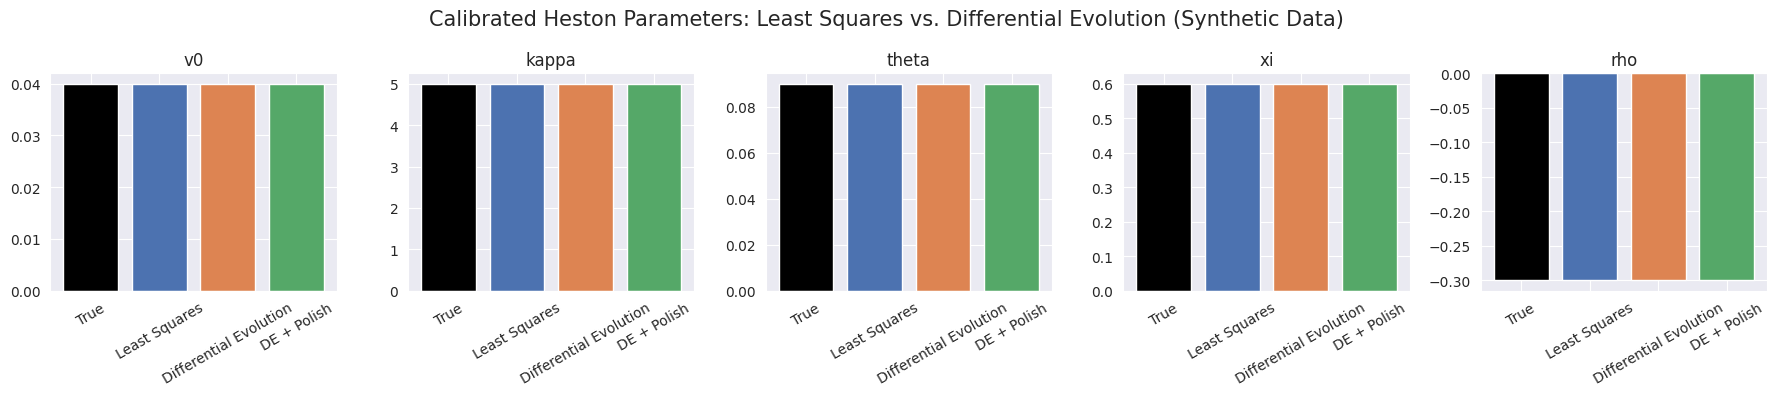

In [ ]:
# Visualization: calibrated parameters vs. ground truth, Least Squares vs. Differential Evolution
param_names = ['v0', 'kappa', 'theta', 'xi', 'rho']
methods = {
    'True': true_params,
    'Least Squares': result_ls.x,
    'Differential Evolution': result_de.x,
    'DE + Polish': result_de_polished.x,
}
colors = ['black', '#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, name in zip(axes, param_names):
    idx = param_names.index(name)
    values = [methods[m][idx] for m in methods]
    ax.bar(list(methods.keys()), values, color=colors)
    ax.set_title(name)
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Calibrated Heston Parameters: Least Squares vs. Differential Evolution (Synthetic Data)', size=15)
fig.tight_layout()
plt.show()

### Robustness to a Poor Initial Guess

The comparison above starts `least_squares` from a reasonable initial guess, which is the best case for a local optimizer. The real advantage of `differential_evolution` shows up when the initial guess is bad: `least_squares` has no way to recover, while `differential_evolution` never used an initial guess in the first place, so it is unaffected.

In [ ]:
# Deliberately poor initial guess: far from the true parameters, near a corner of the bounds
bad_guess = [0.75, 0.5, 0.75, 4.5, -0.05]
print('Deliberately poor initial guess:  ', np.round(bad_guess, 4))
print('True Parameters:                 ', np.round(true_params, 4))
print('=' * 75)

start_ls_bad = time.perf_counter()
result_ls_bad = least_squares(error_price_carr_madan, x0=bad_guess, bounds=bounds,
                               args=(S0_syn, strikes_syn, ttes_syn, r, heston_prices_syn), verbose=0)
end_ls_bad = time.perf_counter()

start_de_bad = time.perf_counter()
result_de_bad = differential_evolution(sse_price_carr_madan, bounds=de_bounds,
                                        args=(S0_syn, strikes_syn, ttes_syn, r, heston_prices_syn),
                                        popsize=8, maxiter=12, tol=1e-2, seed=42)
end_de_bad = time.perf_counter()

ls_bad_error = np.sqrt(np.mean((result_ls_bad.x - true_params)**2))
de_bad_error = np.sqrt(np.mean((result_de_bad.x - true_params)**2))

print(f"Least Squares from bad guess:     {np.round(result_ls_bad.x, 4)}  |  RMSE to true params: {ls_bad_error:.4f}")
print(f"Differential Evolution (same as before, ignores the bad guess entirely): RMSE to true params: {de_bad_error:.4f}")
print('=' * 75)
if ls_bad_error > 5 * de_bad_error:
    print('Least Squares got stuck far from the true parameters; Differential Evolution recovered them regardless of starting point.')
else:
    print('On this particular synthetic surface, Least Squares recovered reasonably well even from a poor guess -- '
          'not every bad initial guess leads to a bad local minimum, but Differential Evolution never depends on getting lucky.')

Deliberately poor initial guess:   [ 0.75  0.5   0.75  4.5  -0.05]
True Parameters:                  [ 0.04  5.    0.09  0.6  -0.3 ]
Least Squares from bad guess:     [ 0.01    4.1665  0.2022  5.     -0.2012]  |  RMSE to true params: 2.0039
Differential Evolution (same as before, ignores the bad guess entirely): RMSE to true params: 0.0003
Least Squares got stuck far from the true parameters; Differential Evolution recovered them regardless of starting point.


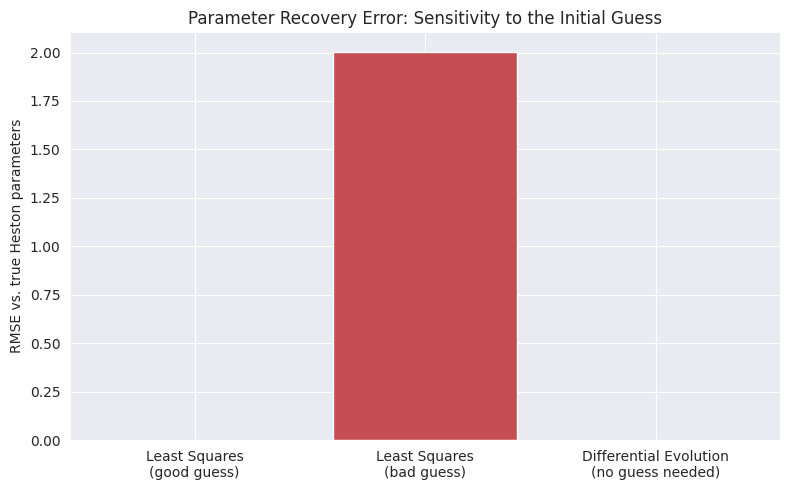

In [ ]:
# Visualization: parameter recovery error (RMSE to ground truth), good guess vs. bad guess
fig, ax = plt.subplots(figsize=(8, 5))
labels = ['Least Squares\n(good guess)', 'Least Squares\n(bad guess)', 'Differential Evolution\n(no guess needed)']
rmses = [
    np.sqrt(np.mean((result_ls.x - true_params)**2)),
    ls_bad_error,
    de_bad_error,
]
ax.bar(labels, rmses, color=['#4C72B0', '#C44E52', '#DD8452'])
ax.set_ylabel('RMSE vs. true Heston parameters')
ax.set_title('Parameter Recovery Error: Sensitivity to the Initial Guess')
fig.tight_layout()
plt.show()

In [ ]:
# ==================================================================================
# Fitting TSLA DATA
# ==================================================================================

print("Loading TSLA options data...")
path = kagglehub.dataset_download("kylegraupe/tsla-daily-eod-options-quotes-2019-2022")

option_data = pd.read_csv(
    os.path.join(path, "tsla_2019_2022.csv"),
    low_memory=False
)

### Variables Used from the Tesla Options Dataset

The following columns are extracted from the TSLA dataset and used for Heston model calibration.

| Variable | Description |
|----------|-------------|
| `QUOTE_DATE` | Date on which the option quote was observed. Each row is market data for this trading day. |
| `UNDERLYING_LAST` | Closing price of the underlying Tesla stock on the quote date ($S_0$). |
| `EXPIRE_DATE` | Expiration date of the option contract. |
| `DTE` | **Days to Expiration.** Calendar days remaining until option expires. |
| `C_IV` | **Call Implied Volatility.** Implied volatility from Black–Scholes model. |
| `C_SIZE` | Quoted market depth (`"bid_size x ask_size"`), indicating contracts available at best bid and ask prices. |
| `C_BID` | Highest price buyers are willing to pay for the call option. |
| `C_ASK` | Lowest price sellers are willing to accept for the call option. |
| `STRIKE` | Strike price $K$ of the option contract. |
| `STRIKE_DISTANCE_PCT` | Percentage distance between strike price and underlying stock price. |

## Data Preprocessing

### Extract Bid and Ask Sizes

The `C_SIZE` column stores the market depth in the format `bid_size x ask_size` (e.g., `25x18`). It is split into two numerical variables:

```python
sizes = call_data[' [C_SIZE]'].str.split('x', expand=True).astype(float)
call_data['bid_size'] = sizes[0]
call_data['ask_size'] = sizes[1]
```

These variables are used to identify liquid options.

---

### Filter the Dataset

The dataset is filtered to retain only reliable option contracts:

- `min_DTE < DTE < max_DTE`: keeps medium-term options.
- `bid_size > min_bid_size` and `ask_size > min_bid_size`: removes illiquid options.
- `STRIKE_DISTANCE_PCT < min_strike_distance_pct`: keeps options close to the money.
- `UNDERLYING_LAST < max_strike_price`: restricts the sample to stock prices below max_strike_price.

---

### Compute Market Prices

The bid, ask, and implied volatility columns are converted to numeric values. For each row, we do the fitting using two values of option market price. The midpoint of the bid-ask spread, and the weighted average


$\text{mid}=\frac{\text{bid}+\text{ask}}{2},$ 

$\text{weighted} = \frac{\text{bid-size}*\text{bid}+\text{ask-size}*\text{ask}}{\text{ask-size}+\text{bid-size}},$

and the time to expiration is converted from days to years,

$
T=\frac{\text{DTE}}{365}.
$

---

### Compute Implied Volatilities

Using the market prices, the Black--Scholes implied volatility is computed for each option,

```python
call_data['iv_mid'] = bs_call_iv_vectorized(spots, strikes, ttes, r, prices_mid)
call_data['iv_weighted'] = bs_call_iv_vectorized(spots, strikes, ttes, r, prices_weighted)
```

Options for which the implied volatility cannot be computed are removed:

```python
call_data = call_data.dropna()
```

---

### Calibration Inputs

The final arrays used for calibration are:

- `spots`: underlying stock prices \(S_0\),
- `strikes`: strike prices \(K\),
- `prices_mid`: mid-market option prices,
- `prices_weighted`: weighted-market option prices,
- `ttes`: times to expiration \(T\) in years,
- `iv`: Black--Scholes implied volatilities computed from the observed market prices.

In [ ]:
#Get required columns

call_data = option_data[[' [QUOTE_DATE]', ' [UNDERLYING_LAST]',' [EXPIRE_DATE]',
                      ' [DTE]',' [C_IV]', ' [C_SIZE]', ' [C_BID]', ' [C_ASK]',
                      ' [STRIKE]', ' [STRIKE_DISTANCE_PCT]']].copy()

sizes = call_data[' [C_SIZE]'].str.split('x', expand=True).astype(float)
call_data['bid_size'] = sizes[0]
call_data['ask_size'] = sizes[1]

#Filter the dataset

min_bid_size = 10
min_ask_size = 10
min_DTE = 0
max_DTE = 300
max_strike_distance_pct = .5
max_spot_price = 300

call_data = call_data[
    (call_data['bid_size'] > min_bid_size) & (call_data['ask_size'] > min_ask_size)
    & (call_data[' [DTE]'] < max_DTE) & ((call_data[' [DTE]'] > min_DTE))
    & (call_data[' [STRIKE_DISTANCE_PCT]'] < max_strike_distance_pct) & (call_data[' [UNDERLYING_LAST]'] < max_spot_price)
].copy()

call_data[' [C_IV]'] = pd.to_numeric(call_data[' [C_IV]'].str.strip())
call_data[' [C_BID]'] = pd.to_numeric(call_data[' [C_BID]'])
call_data[' [C_ASK]'] = pd.to_numeric(call_data[' [C_ASK]'])

call_data['mid'] = (0.5) * (call_data[' [C_BID]'] + call_data[' [C_ASK]'])
call_data['weighted'] = (call_data['bid_size'] * call_data[' [C_BID]'] + call_data['ask_size'] * call_data[' [C_ASK]'])\
                         /(call_data['bid_size'] + call_data['ask_size'])
call_data['tte'] = call_data[' [DTE]'] / 365

#Get calibration inputs

spots = call_data[' [UNDERLYING_LAST]'].values
strikes = call_data[' [STRIKE]'].values
prices_weighted = call_data['weighted'].values
prices_mid = call_data['mid'].values
ttes = call_data['tte'].values

call_data['iv_mid'] = bs_call_iv_vectorized(spots,strikes,ttes,r,prices_mid)
call_data['iv_weighted'] = bs_call_iv_vectorized(spots,strikes,ttes,r,prices_weighted)

call_data = call_data.dropna()
call_data[' [QUOTE_DATE]'] = call_data[' [QUOTE_DATE]'].str.strip()
quote_dates = np.unique(call_data[' [QUOTE_DATE]'].values)

## Calibrating Heston to a Single Day of TSLA Options

Having validated Carr–Madan against direct numerical integration on synthetic
data, we now calibrate the Heston model to real market quotes. We pick a
single quote date `qd = quote_dates[20]` and extract all TSLA call options
traded on that day: strikes, mid and weighted prices, times to expiration, spot price
$S_0$, and Black–Scholes implied volatilities.

In [ ]:
qd = quote_dates[20]

X = call_data[call_data[' [QUOTE_DATE]']==qd].copy()
strikes = X[' [STRIKE]'].values
market_prices_weighted = X['weighted'].values
market_prices_mid = X['mid'].values
ttes = X['tte'].values
market_ivs_mid = X['iv_mid'].values
market_ivs_weighted = X['iv_weighted'].values
S0 = X[' [UNDERLYING_LAST]'].iloc[0]

market_vegas_mid = bs_vega(S0,strikes,market_ivs_mid,ttes,r)
market_vegas_weighted = bs_vega(S0,strikes,market_ivs_weighted,ttes,r)

v0_initial = .4**2
kappa_initial = 3
theta_initial = .4**2
xi_initial = .5
rho_initial = -.5

parameters = [v0_initial, kappa_initial,theta_initial,xi_initial,rho_initial]

bounds = [[.1**2,.2,.1**2,.5,-.99],[.9**2,15,.9**2, 5,-.01]]

# ==============================================================
# Carr–Madan calibration (mid)
# ==============================================================

start_price_fft_mid = time.perf_counter()

result_de_price_mid = differential_evolution(sse_price_carr_madan, bounds=de_bounds,
                                    args=(S0, strikes, ttes, r, market_prices_mid),
                                    popsize=8, maxiter=12, tol=1e-2, seed=42)

result_price_fft_mid = least_squares(
    error_price_carr_madan,
    x0=result_de_price_mid.x,
    bounds=bounds,
    args=(S0, strikes, ttes, r, market_prices_mid),
    verbose=0
)

end_price_fft_mid = time.perf_counter()


start_iv_fft_mid = time.perf_counter()

result_de_iv_mid = differential_evolution(sse_iv_carr_madan, bounds=de_bounds,
                                    args=(S0, strikes, ttes, r, market_ivs_mid),
                                    popsize=8, maxiter=12, tol=1e-2, seed=42)


result_iv_fft_mid = least_squares(
    error_iv_carr_madan,
    x0=result_de_iv_mid.x,
    bounds=bounds,
    args=(S0, strikes, ttes, r, market_ivs_mid),
    verbose=0
)

end_iv_fft_mid = time.perf_counter()

print("Carr–Madan calibration (Price) using mid price")
print(result_price_fft_mid.message)
print(result_price_fft_mid.x)
print(f'Final RMSE Error is : {np.mean(result_price_fft_mid.fun**2):.6f}')
print(f"Runtime: {end_price_fft_mid-start_price_fft_mid:.3f} seconds")

print('-----------'*10)
print('-----------'*10)

print("Carr–Madan calibration (IV)")
print(result_iv_fft_mid.message)
print(result_iv_fft_mid.x)
print(f'Final RMSE Error is : {np.mean(result_iv_fft_mid.fun**2):.6f}')
print(f"Runtime: {end_iv_fft_mid-start_iv_fft_mid:.3f} seconds")

print('-----------'*10)
print('-----------'*10)

# ==============================================================
# Direct Integration calibration (mid)
# ==============================================================

start_price_mid = time.perf_counter()

result_price_mid = least_squares(error_price, x0 = parameters,bounds = bounds,\
                             args = (S0,strikes,ttes,r,market_prices_mid), verbose = 0)
end_price_mid = time.perf_counter()

start_iv_mid = time.perf_counter()

result_iv_mid = least_squares(error_iv, x0 = parameters,bounds = bounds,\
                             args = (S0,strikes,ttes,r,market_ivs_mid), verbose = 0)

end_iv_mid = time.perf_counter()

print('Least Squares Convergence Message for minimizing pricing errors using mid price:')
print(result_price_mid.message)
print('Calibrated Parameters for minimizing price errors using mid price:')
print(result_price_mid.x)
print(f'Final RMSE Error is : {np.mean(result_price_mid.fun**2):.6f}')
print(f'Time needed to calibrate Heston model from minimizing pricing error using mid price : {end_price_mid - start_price_mid} seconds')

print('-----------'*10)
print('-----------'*10)

print('Least Squares Convergence Message for minimizing iv errors:')
print(result_iv_mid.message)
print('Calibrated Parameters for minimizing iv errors:')
print(result_iv_mid.x)
print(f'Final RMSE Error is : {np.mean(result_iv_mid.fun**2):.6f}')
print(f'Time needed to calibrate Heston model from minimizing iv error: {end_iv_mid - start_iv_mid} seconds')

Carr–Madan calibration (Price) using mid price
`ftol` termination condition is satisfied.
[ 0.32653018  3.46993272  0.43906041  2.38020591 -0.59799698]
Final RMSE Error is : 0.238521
Runtime: 36.706 seconds
--------------------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------
Carr–Madan calibration (IV)
`xtol` termination condition is satisfied.
[ 0.29282037  0.37861401  0.74727427  1.33677774 -0.45345498]
Final RMSE Error is : 0.013093
Runtime: 73.534 seconds
--------------------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------
Least Squares Convergence Message for minimizing pricing errors using mid price:
`ftol` termination condition is satisfied.
Calibrated Parameters for minimizing 

In [ ]:
# ==============================================================
# Carr–Madan calibration (weighted)
# ==============================================================

start_price_fft_weighted = time.perf_counter()

result_de_price_weighted = differential_evolution(sse_price_carr_madan, bounds=de_bounds,
                                    args=(S0, strikes, ttes, r, market_prices_weighted),
                                    popsize=8, maxiter=12, tol=1e-2, seed=42)

result_price_fft_weighted = least_squares(
    error_price_carr_madan,
    x0=result_de_price_weighted.x,
    bounds=bounds,
    args=(S0, strikes, ttes, r, market_prices_weighted),
    verbose=0
)

end_price_fft_weighted = time.perf_counter()


start_iv_fft_weighted = time.perf_counter()

result_de_iv_weighted = differential_evolution(sse_iv_carr_madan, bounds=de_bounds,
                                    args=(S0, strikes, ttes, r, market_ivs_weighted),
                                    popsize=8, maxiter=12, tol=1e-2, seed=42)

result_iv_fft_weighted = least_squares(
    error_iv_carr_madan,
    x0=result_de_iv_weighted.x,
    bounds=bounds,
    args=(S0, strikes, ttes, r, market_ivs_weighted),
    verbose=0
)

end_iv_fft_weighted = time.perf_counter()

print("Carr–Madan calibration (Price) using weighted price")
print(result_price_fft_weighted.message)
print(result_price_fft_weighted.x)
print(f'Final RMSE Error is : {np.mean(result_price_fft_weighted.fun**2):.6f}')
print(f"Runtime: {end_price_fft_weighted-start_price_fft_weighted:.3f} seconds")

print('-----------'*10)
print('-----------'*10)

print("Carr–Madan calibration (IV)")
print(result_iv_fft_weighted.message)
print(result_iv_fft_weighted.x)
print(f'Final RMSE Error is : {np.mean(result_iv_fft_weighted.fun**2):.6f}')
print(f"Runtime: {end_iv_fft_weighted-start_iv_fft_weighted:.3f} seconds")

print('-----------'*10)
print('-----------'*10)

# ==============================================================
# Direct Integration calibration (weighted)
# ==============================================================

start_price_weighted = time.perf_counter()

result_price_weighted = least_squares(error_price, x0 = parameters,bounds = bounds,\
                             args = (S0,strikes,ttes,r,market_prices_weighted), verbose = 0)
end_price_weighted = time.perf_counter()

start_iv_weighted = time.perf_counter()

result_iv_weighted = least_squares(error_iv, x0 = parameters,bounds = bounds,\
                             args = (S0,strikes,ttes,r,market_ivs_weighted), verbose = 0)

end_iv_weighted = time.perf_counter()

print('-----------'*10)
print('-----------'*10)

print('Least Squares Convergence Message for minimizing pricing errors using weighted prices:')
print(result_price_weighted.message)
print('Calibrated Parameters for minimizing price errors using weighted prices:')
print(result_price_weighted.x)
print(f'Final RMSE Error is : {np.mean(result_price_weighted.fun**2):.6f}')
print(f'Time needed to calibrate Heston model from minimizing pricing error using weighted prices: {end_price_weighted - start_price_weighted} seconds')

print('-----------'*10)
print('-----------'*10)

print('Least Squares Convergence Message for minimizing iv errors using weighted prices:')
print(result_iv_weighted.message)
print('Calibrated Parameters for minimizing iv errors using weighted prices:')
print(result_iv_weighted.x)
print(f'Final RMSE Error is : {np.mean(result_iv_weighted.fun**2):.6f}')
print(f'Time needed to calibrate Heston model from minimizing iv error using weighted prices: {end_iv_weighted - start_iv_weighted} seconds')


Starting from the same initial guess and bounds used in the synthetic
experiments above, we run four calibrations for both mid and weighted:

| Pricer | Objective | Result |
|---|---|---|
| Carr–Madan (FFT) | Price error | `result_price_fft_{mid/weighted}` |
| Carr–Madan (FFT) | IV error | `result_iv_fft_{mid/weighted}` |
| Direct integration | Price error | `result_price_{mid/weighted}` |
| Direct integration | IV error | `result_iv_{mid/weighted}` |

Each calibration minimizes a different residual via `least_squares`:
`error_price(_carr_madan)` matches raw dollar prices, while
`error_iv(_carr_madan)` matches implied volatilities instead — this reweights
the fit, since deep OTM/ITM options have tiny prices but their IVs still
carry meaningful information about the volatility smile. We time each run to
compare Carr–Madan's per-evaluation speedup against direct integration on
real (noisier, unevenly spaced) market data rather than a clean synthetic
grid.

### Visualizing the Fit

For each unique maturity $t$ present on this quote date, we plot:

- **Price comparison**: market mid-prices vs. model prices from all three
  fitted parameter sets (Carr–Madan, price-error integration, IV-error
  integration), across strikes.
- **IV comparison**: the same three fits translated into implied vols via
  `bs_call_iv_vectorized`, overlaid on the market's implied volatility smile.

A vertical dashed line marks the spot price $S_0$, so at-the-money fit
quality is easy to eyeball. Comparing the two objectives shows whether
minimizing raw price error under-fits the wings of the smile relative to
minimizing IV error directly, and comparing Carr–Madan vs. direct integration
checks that the FFT method's speed doesn't come at the cost of accuracy on
real, noisy data.

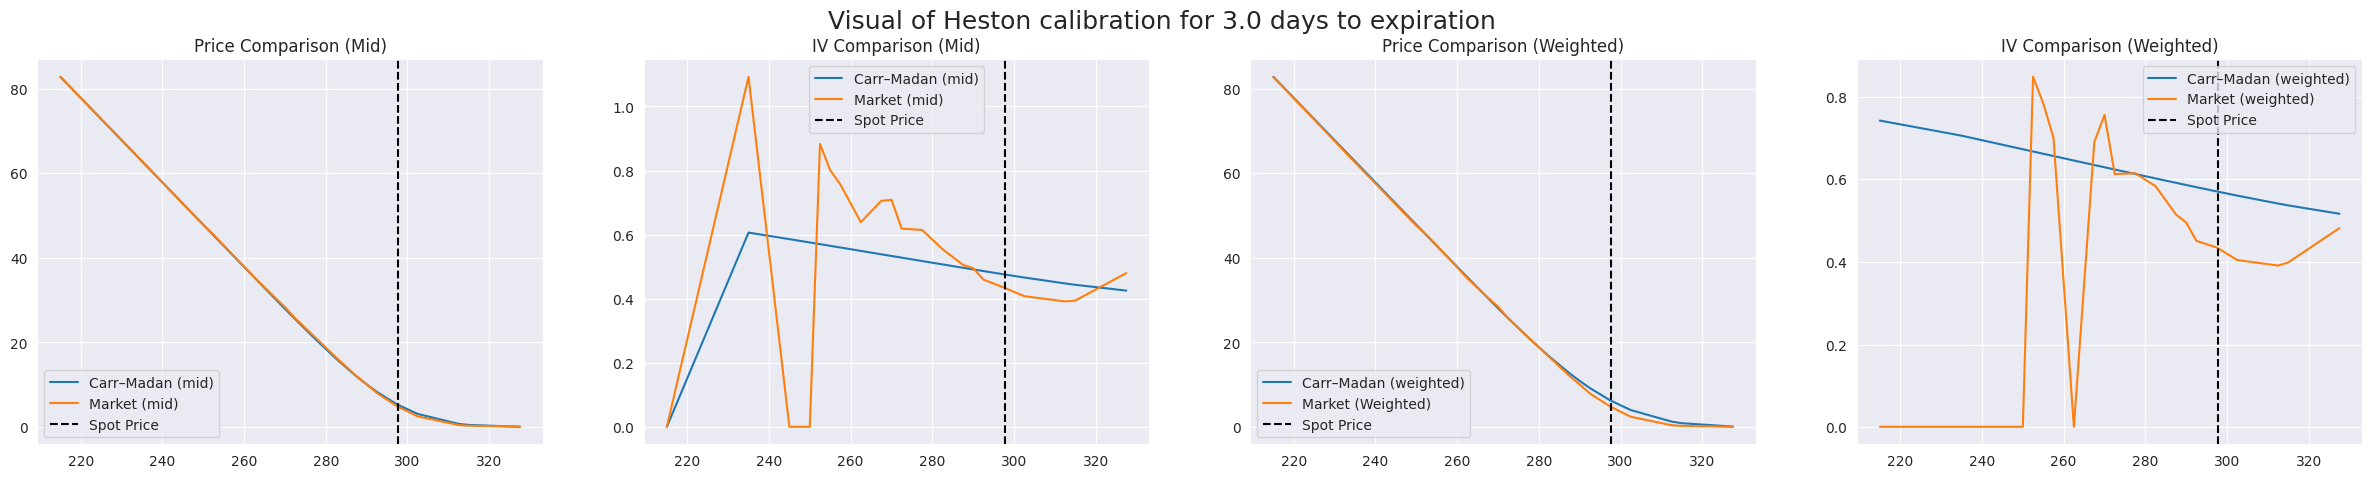

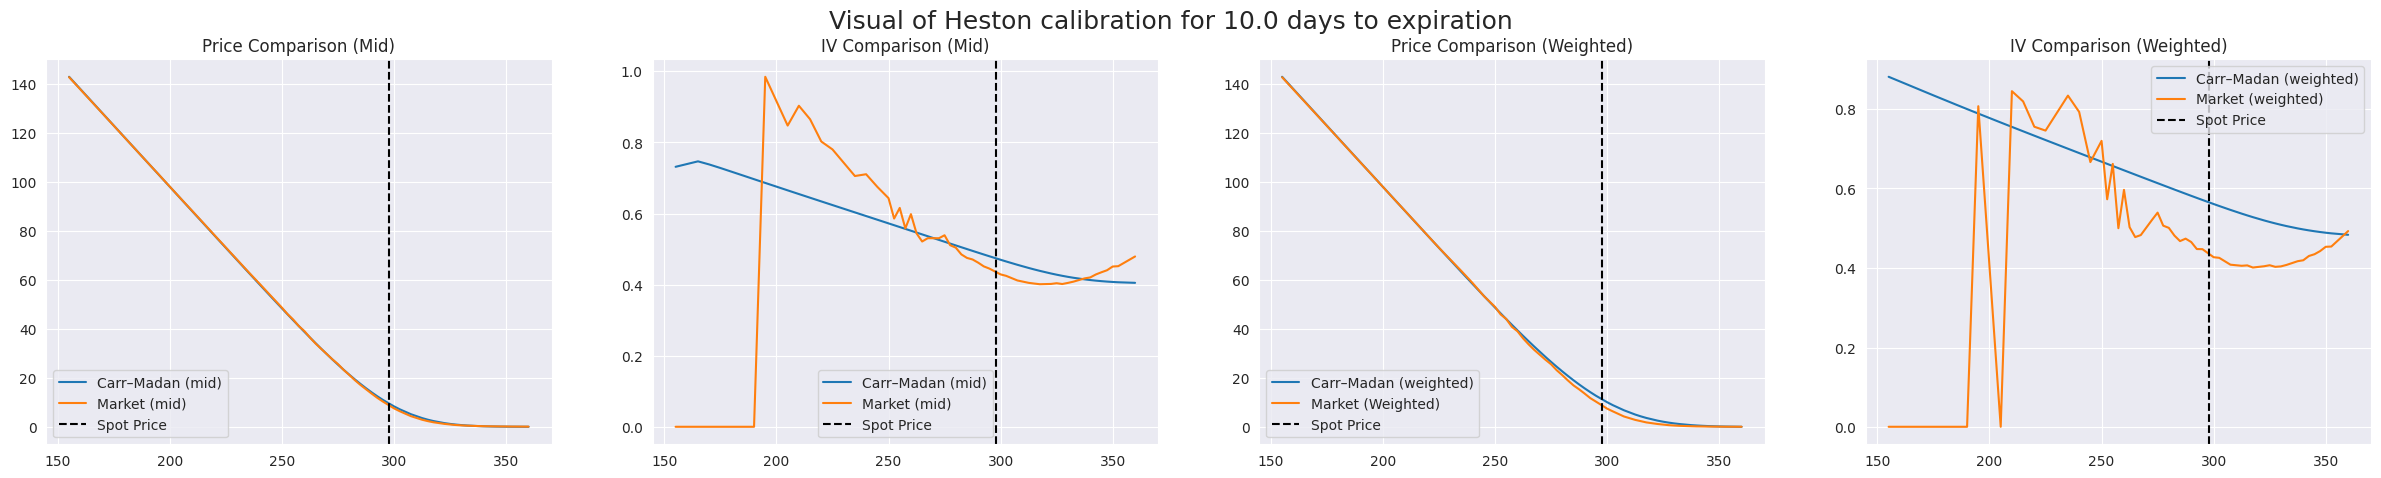

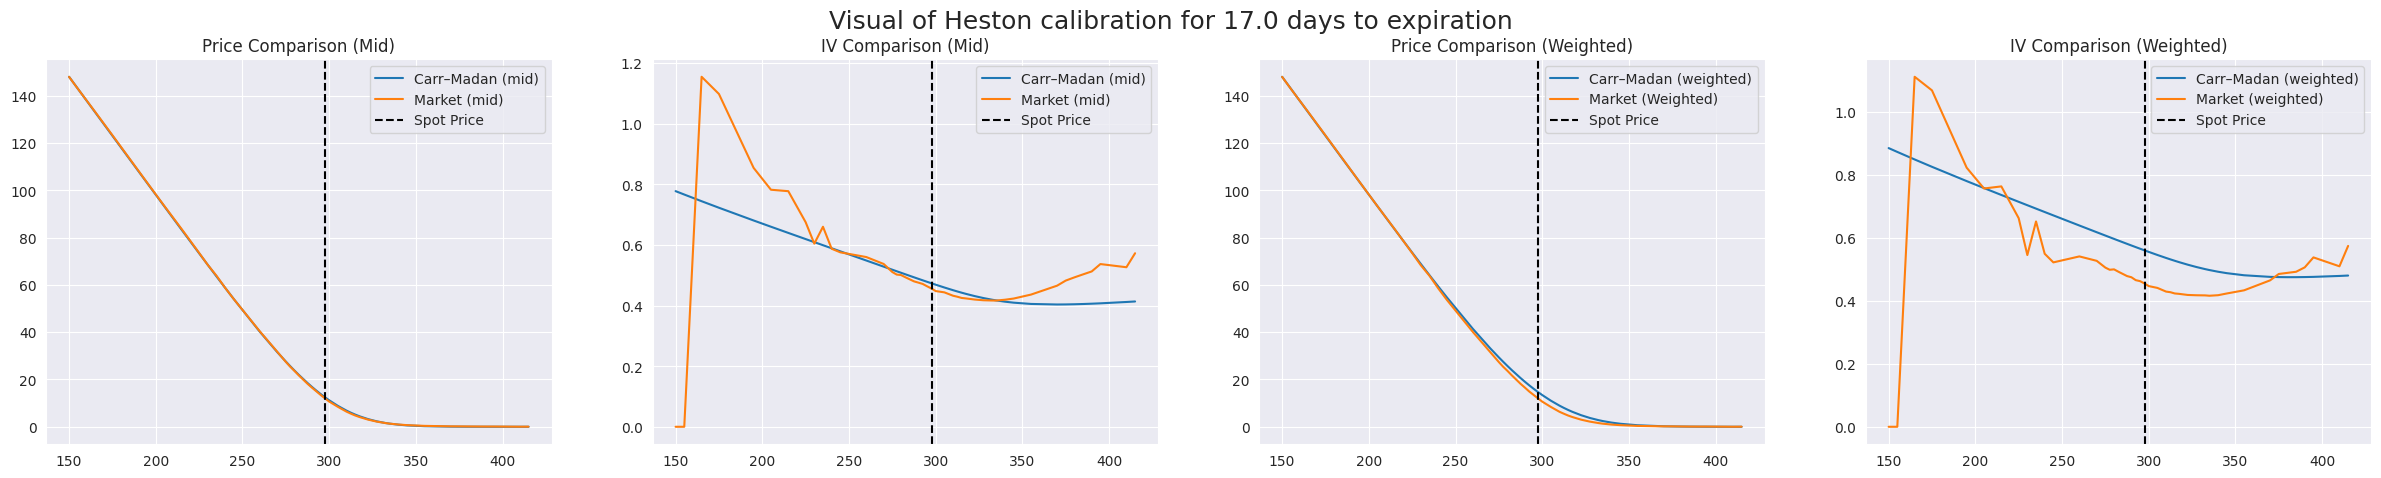

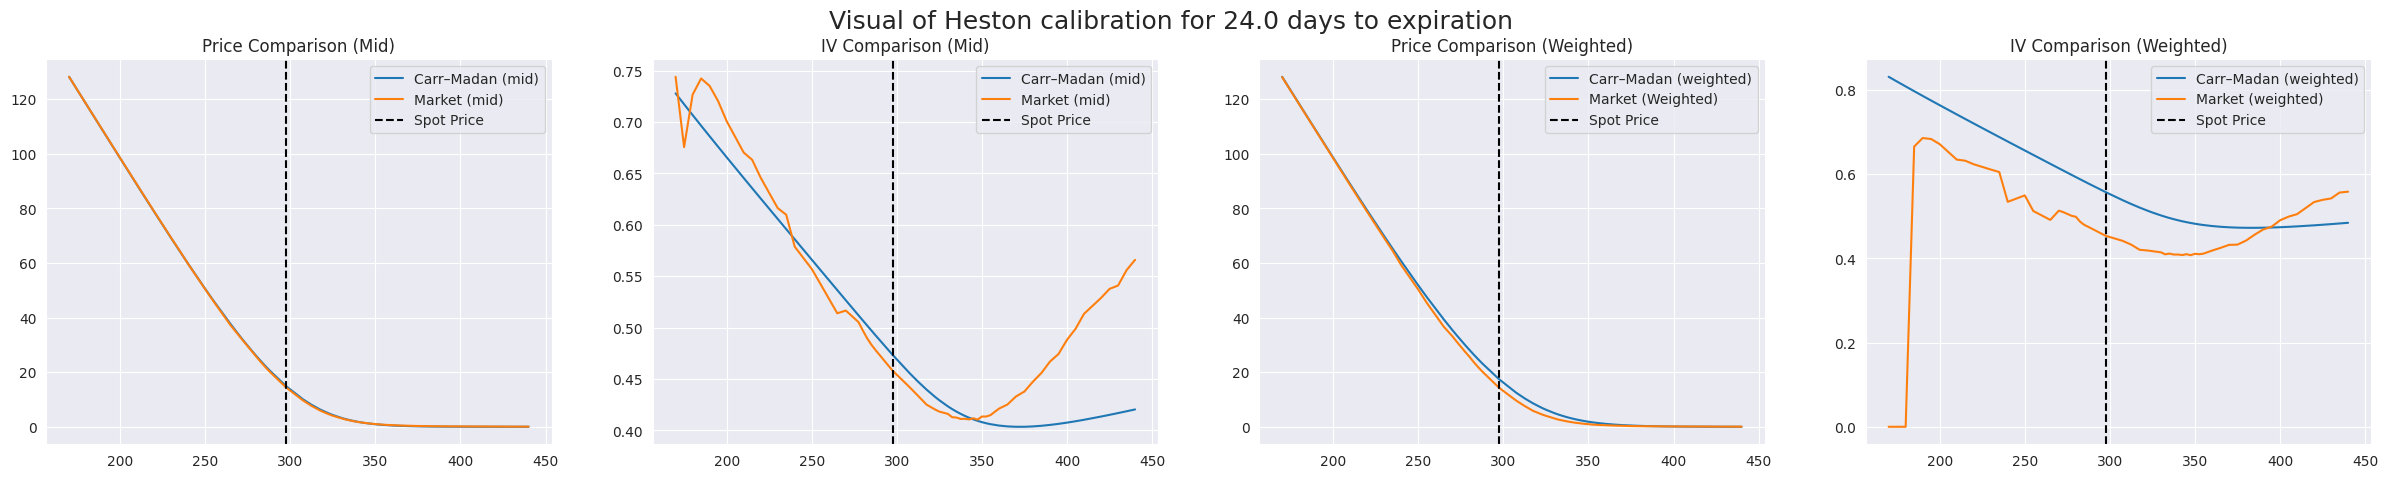

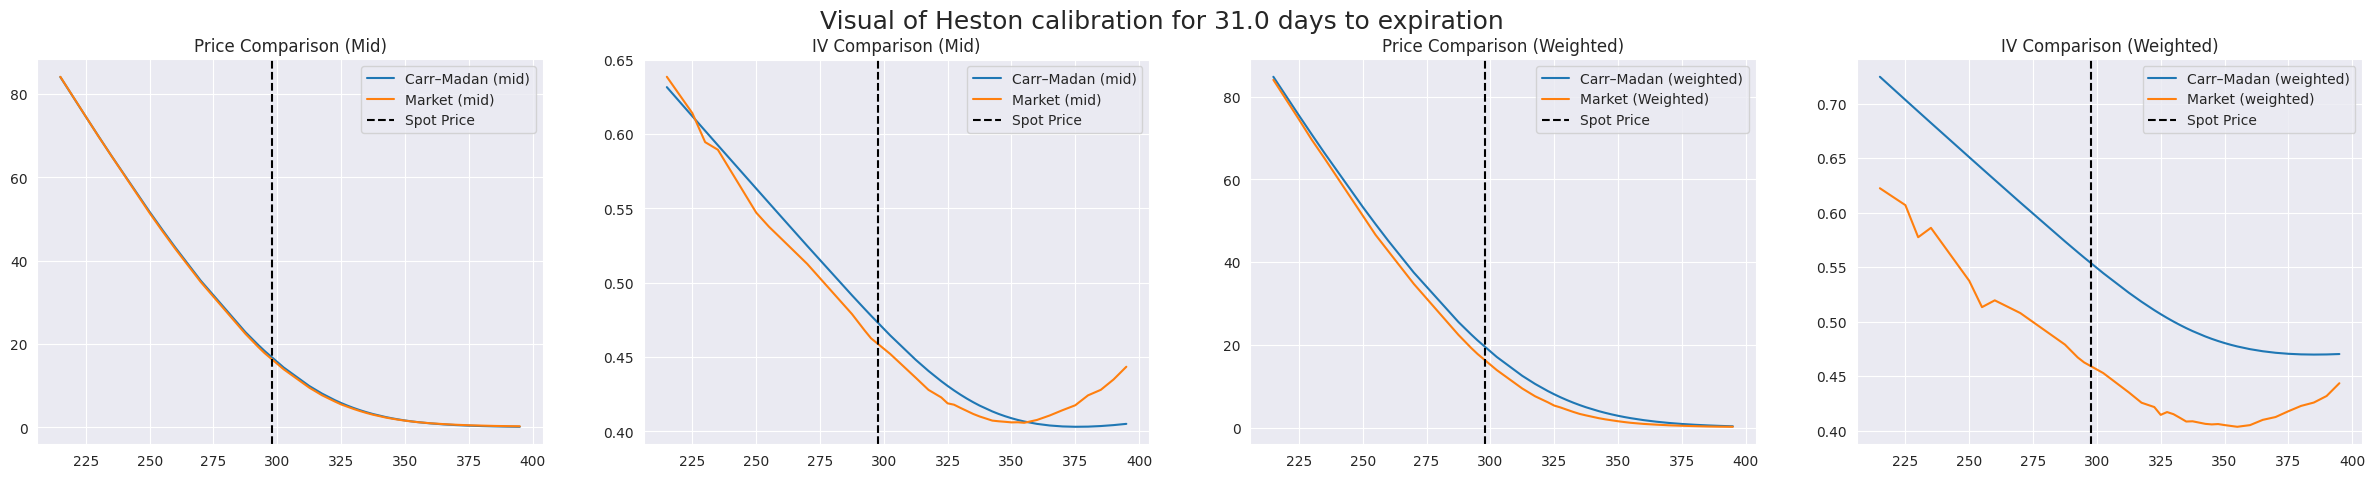

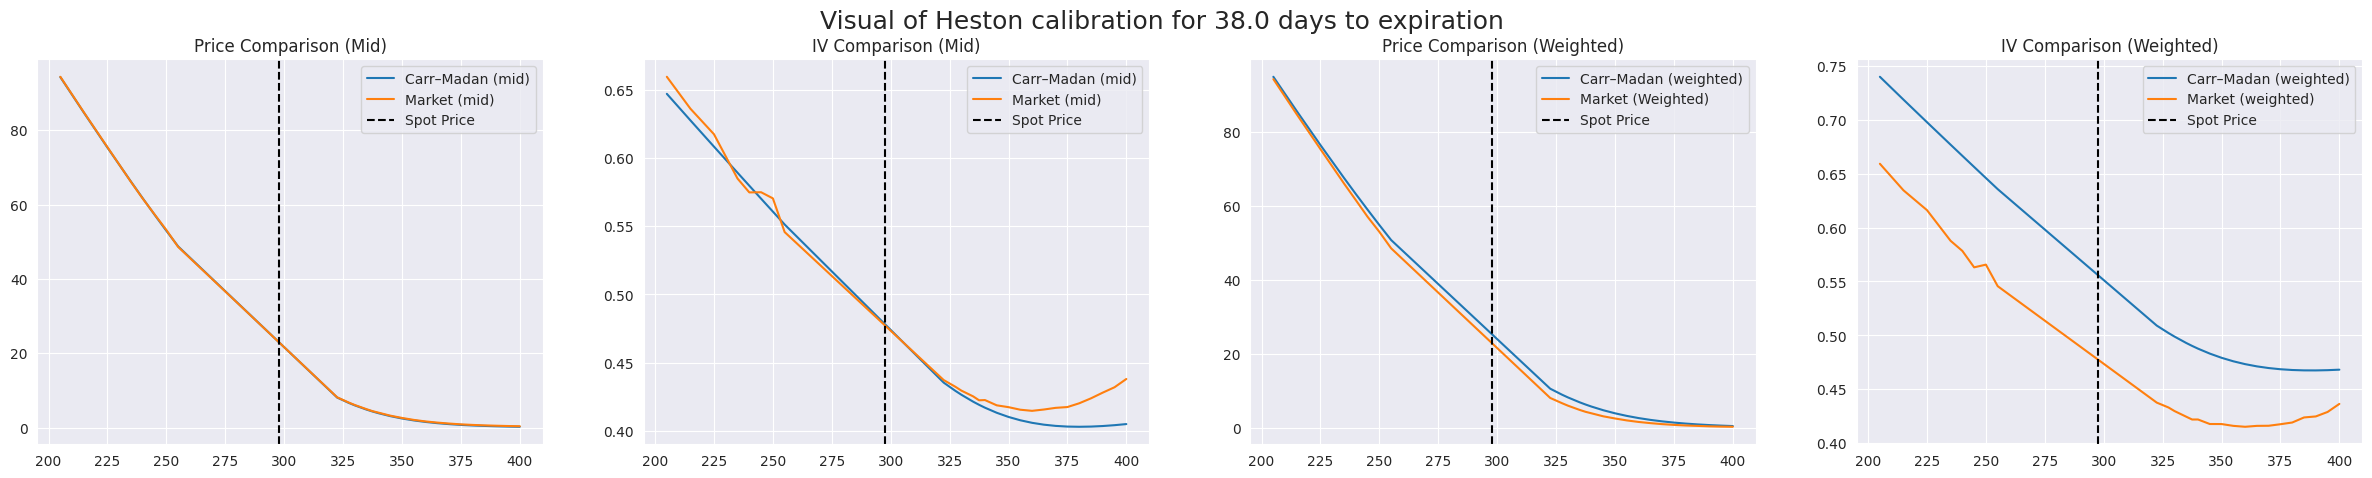

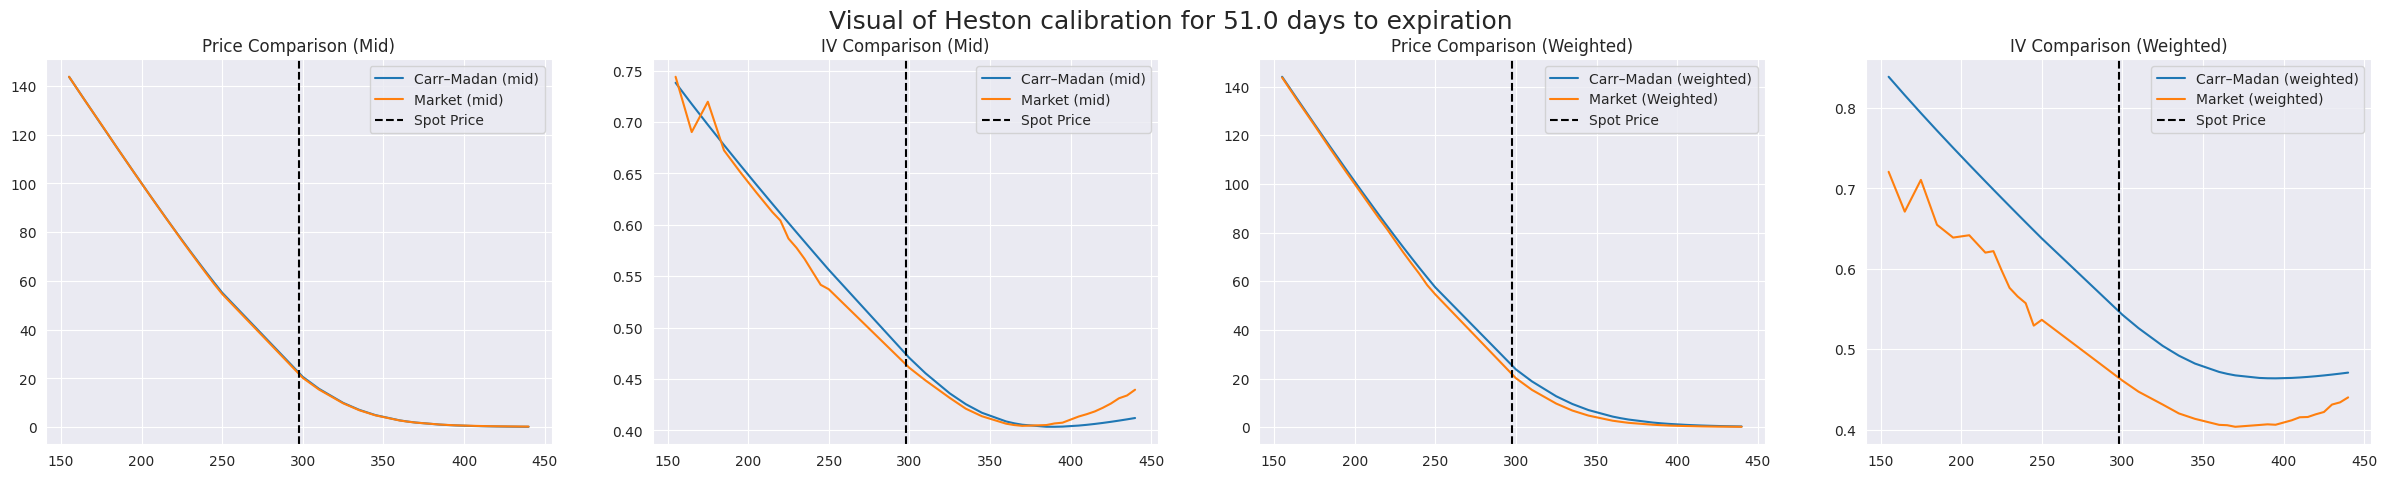

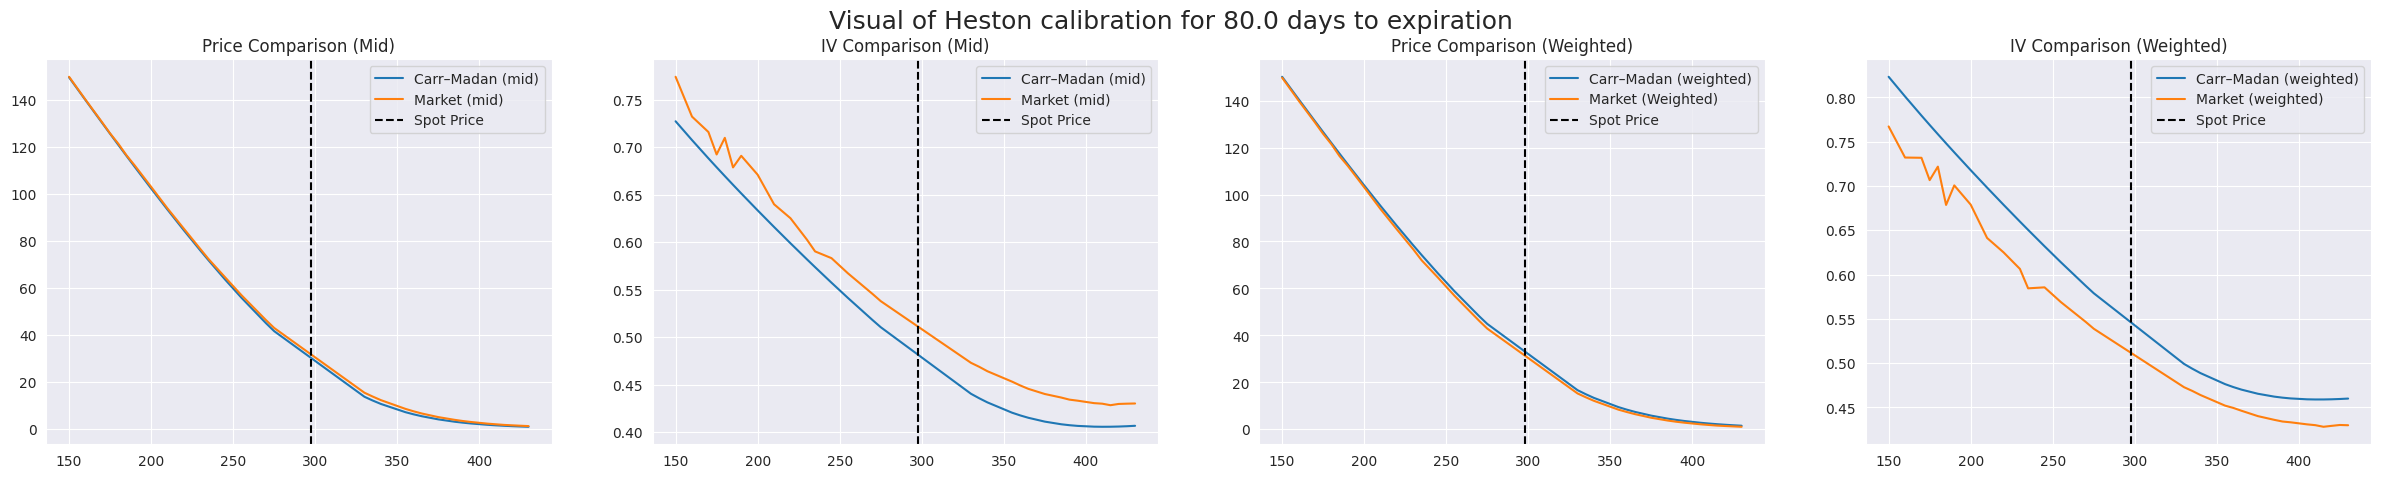

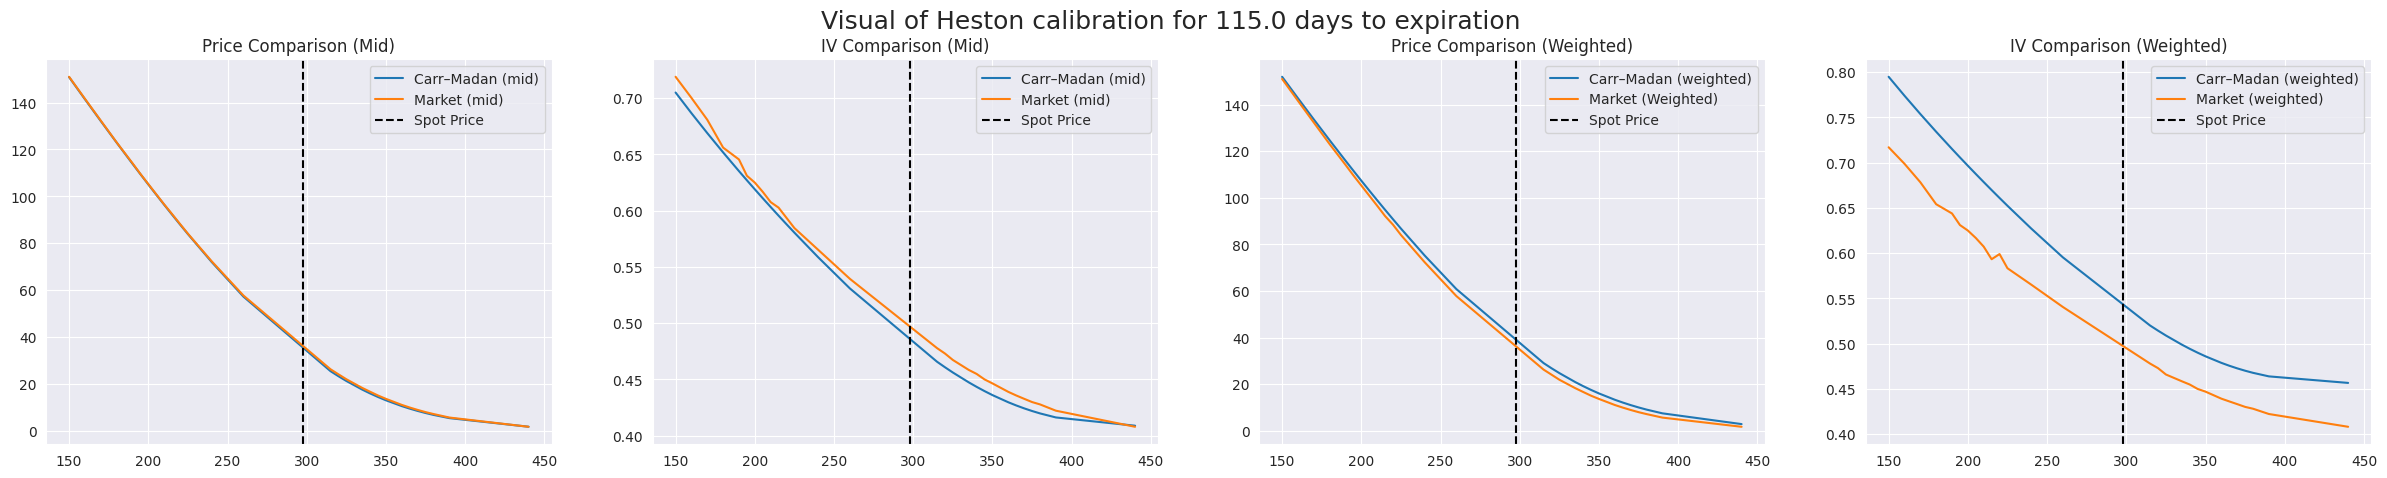

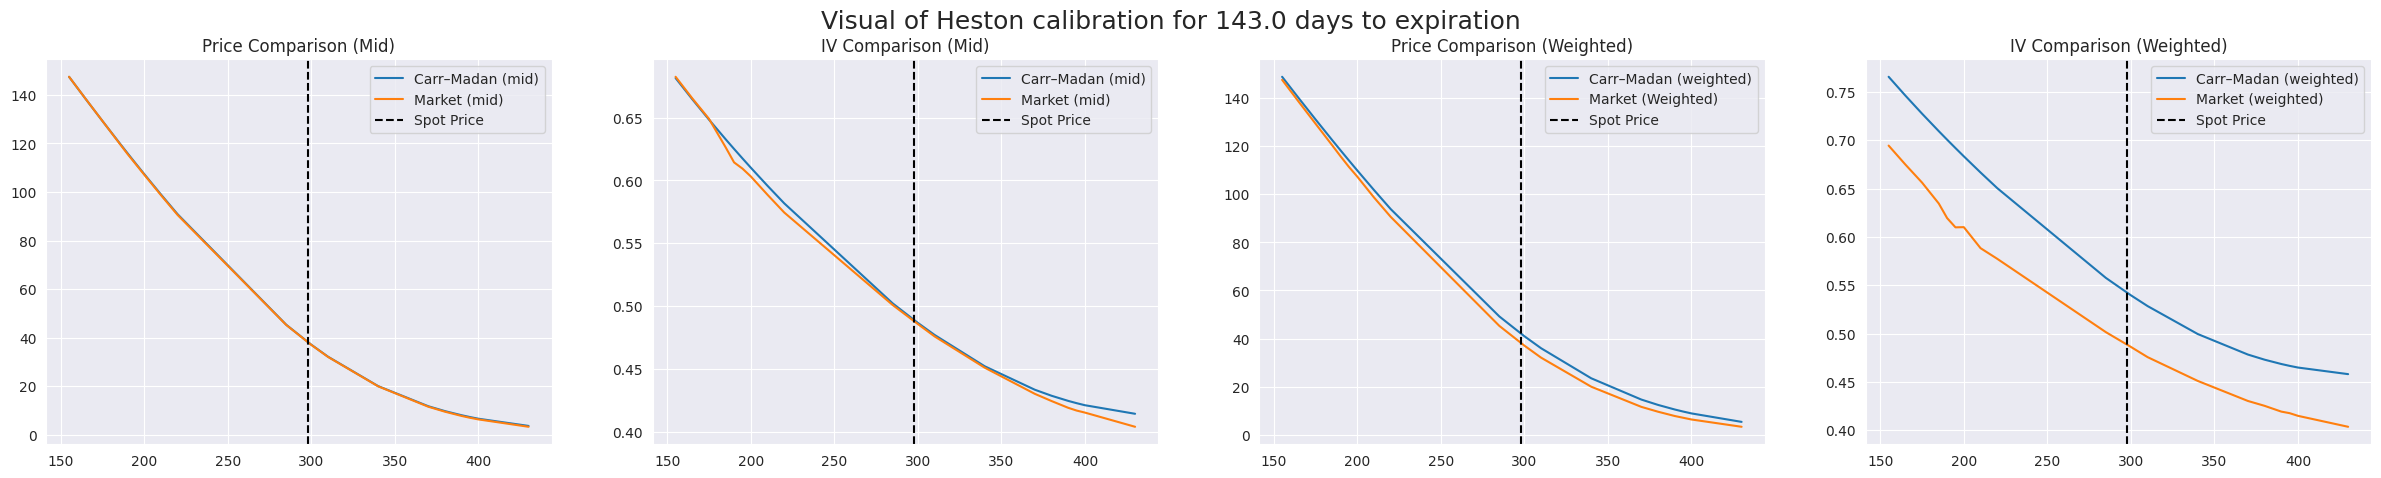

KeyboardInterrupt: 

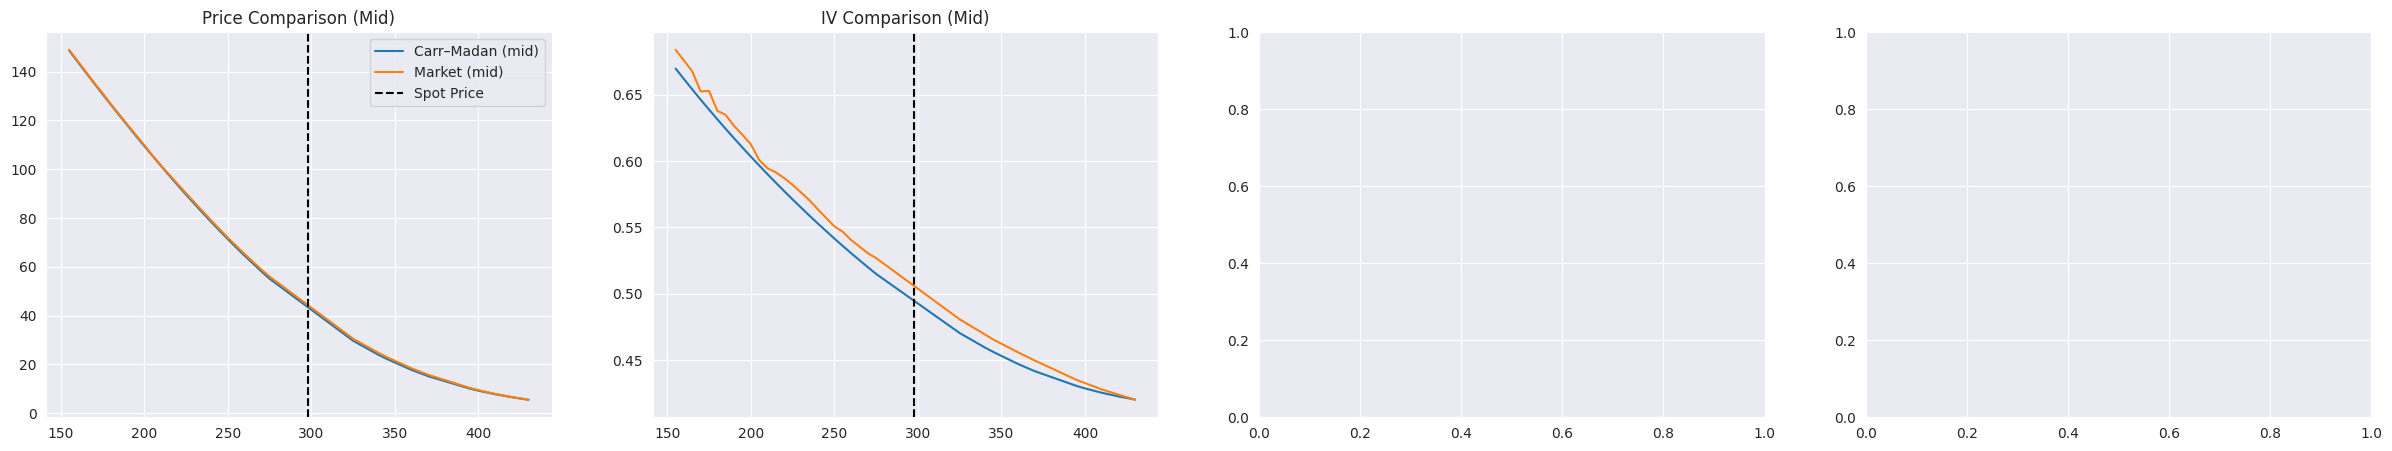

In [ ]:
##Visuals of heston data fitting

v0_price_mid, kappa_price_mid,theta_price_mid,xi_price_mid,rho_price_mid = result_price_mid.x
v0_fft_mid, kappa_fft_mid, theta_fft_mid, xi_fft_mid, rho_fft_mid = result_price_fft_mid.x
v0_iv_mid, kappa_iv_mid,theta_iv_mid, xi_iv_mid, rho_iv_mid = result_iv_mid.x

v0_price_weighted, kappa_price_weighted,theta_price_weighted,xi_price_weighted,rho_price_weighted= result_price_weighted.x
v0_fft_weighted, kappa_fft_weighted, theta_fft_weighted, xi_fft_weighted, rho_fft_weighted = result_price_fft_weighted.x
v0_iv_weighted, kappa_iv_weighted,theta_iv_weighted, xi_iv_weighted, rho_iv_weighted = result_iv_weighted.x


for t in np.unique(X['tte'].values):
    Y = X[X['tte'] == t].copy()

    market_prices_weighted = Y['weighted'].values
    market_prices_mid  = Y['mid'].values
    market_ivs_mid = Y['iv_mid'].values
    market_ivs_weighted = Y['iv_weighted'].values
    strikes = Y[' [STRIKE]'].values

    price_model_prices_mid = heston_call_vectorized(S0,strikes,t*np.ones(len(strikes)),v0_price_mid,r,kappa_price_mid,theta_price_mid,xi_price_mid,rho_price_mid)
    price_model_ivs_mid = bs_call_iv_vectorized(S0*np.ones(len(strikes)),strikes,t*np.ones(len(strikes)),r,price_model_prices_mid)

    price_model_prices_weighted = heston_call_vectorized(S0,strikes,t*np.ones(len(strikes)),v0_price_weighted ,r,kappa_price_weighted ,theta_price_weighted ,xi_price_weighted ,rho_price_weighted)
    price_model_ivs_weighted = bs_call_iv_vectorized(S0*np.ones(len(strikes)),strikes,t*np.ones(len(strikes)),r,price_model_prices_weighted )

    iv_model_prices_mid = heston_call_vectorized(S0,strikes,t*np.ones(len(strikes)),v0_iv_mid,r,kappa_iv_mid,theta_iv_mid,xi_iv_mid,rho_iv_mid)
    iv_model_ivs_mid = bs_call_iv_vectorized(S0*np.ones(len(strikes)),strikes,t*np.ones(len(strikes)),r,iv_model_prices_mid)

    iv_model_prices_weighted = heston_call_vectorized(S0,strikes,t*np.ones(len(strikes)),v0_iv_weighted,r,kappa_iv_weighted,theta_iv_weighted,xi_iv_weighted,rho_iv_weighted)
    iv_model_ivs_weighted = bs_call_iv_vectorized(S0*np.ones(len(strikes)),strikes,t*np.ones(len(strikes)),r,iv_model_prices_weighted)

    fft_model_prices_mid = np.array([
    heston_call_carr_madan(S0, K, v0_fft_mid, r, t, kappa_fft_mid, theta_fft_mid, xi_fft_mid, rho_fft_mid)
    for K in strikes
    ])

    fft_model_prices_weighted = np.array([
    heston_call_carr_madan(S0, K, v0_fft_weighted, r, t, kappa_fft_weighted, theta_fft_weighted, xi_fft_weighted, rho_fft_weighted)
    for K in strikes
    ])

    fft_model_ivs_mid = bs_call_iv_vectorized(
        S0*np.ones(len(strikes)),
        strikes,
        t*np.ones(len(strikes)),
        r,
        fft_model_prices_mid
    )

    fft_model_ivs_weighted = bs_call_iv_vectorized(
        S0*np.ones(len(strikes)),
        strikes,
        t*np.ones(len(strikes)),
        r,
        fft_model_prices_weighted
    )

    fig,ax = plt.subplots(1,4,figsize = (30,5))

    ax[0].plot(strikes, fft_model_prices_mid, label="Carr–Madan (mid)")
    ax[0].plot(strikes,market_prices_mid, label = 'Market (mid)')
    #ax[0].plot(strikes,price_model_prices, label = 'Model of Minimizing Price Errors')
    #ax[0].plot(strikes,iv_model_prices_mid, label = 'Model of Minimizing IV Errors')
    ax[0].axvline(S0,ls = '--', color = 'black', label = 'Spot Price')
    ax[0].set_title('Price Comparison (Mid)')
    ax[0].legend()

    ax[1].plot(strikes, fft_model_ivs_mid, label="Carr–Madan (mid)")
    ax[1].plot(strikes,market_ivs_mid, label = 'Market (mid)')
    #ax[1].plot(strikes,price_model_ivs, label = 'Model of Minimizing Price Errors')
    #ax[1].plot(strikes,iv_model_ivs_mid, label = 'Model of Minimizing IV Errors')
    ax[1].axvline(S0,ls = '--', color = 'black', label = 'Spot Price')
    ax[1].set_title('IV Comparison (Mid)')
    ax[1].legend()

    ax[2].plot(strikes, fft_model_prices_weighted, label="Carr–Madan (weighted)")
    ax[2].plot(strikes,market_prices_weighted, label = 'Market (Weighted)')
    ax[2].axvline(S0,ls = '--', color = 'black', label = 'Spot Price')
    ax[2].set_title('Price Comparison (Weighted)')
    ax[2].legend()

    ax[3].plot(strikes, fft_model_ivs_weighted, label="Carr–Madan (weighted)")
    ax[3].plot(strikes,market_ivs_weighted, label = 'Market (weighted)')
    ax[3].axvline(S0,ls = '--', color = 'black', label = 'Spot Price')
    ax[3].set_title('IV Comparison (Weighted)')
    ax[3].legend()

    plt.suptitle(f'Visual of Heston calibration for {365*t:.1f} days to expiration', size = 18)
    plt.show()

# How the calibrated parameters change on changing quote date

In [ ]:
#Examine Calibrated parameters over time
#We compare parameters calibrated using polished differential evolution according to error_price metric and Carr-Madan FFT

start = 5
for i in range(start,start+5):
  qd = quote_dates[i]

  X = call_data[call_data[' [QUOTE_DATE]']==qd].copy()
  strikes = X[' [STRIKE]'].values
  market_prices_weighted = X['weighted'].values
  market_prices_mid = X['mid'].values
  ttes = X['tte'].values
  market_ivs_mid = X['iv_mid'].values
  market_ivs_weighted = X['iv_weighted'].values
  S0 = X[' [UNDERLYING_LAST]'].iloc[0]

  market_vegas_mid = bs_vega(S0,strikes,market_ivs_mid,ttes,r)
  market_vegas_weighted = bs_vega(S0,strikes,market_ivs_weighted,ttes,r)

  v0_initial = .4**2
  kappa_initial = 3
  theta_initial = .4**2
  xi_initial = .5
  rho_initial = -.5

  parameters = [v0_initial, kappa_initial,theta_initial,xi_initial,rho_initial]

  bounds = [[.1**2,.2,.1**2,.5,-.99],[.9**2,15,.9**2, 5,-.01]]

  # ==============================================================
  # Carr–Madan calibration (mid)
  # ==============================================================

  result_de_price_mid = differential_evolution(sse_price_carr_madan, bounds=de_bounds,
                                      args=(S0, strikes, ttes, r, market_prices_mid),
                                      popsize=8, maxiter=12, tol=1e-2, seed=42)

  result_price_fft_mid = least_squares(
      error_price_carr_madan,
      x0=result_de_price_mid.x,
      bounds=bounds,
      args=(S0, strikes, ttes, r, market_prices_mid),
      verbose=0
  )

  print(qd)
  print(result_price_fft_mid.message)
  print(result_price_fft_mid.x)
  print(f'Final RMSE Error is : {np.mean(result_price_fft_mid.fun**2):.6f}')

  print('-----------'*10)
  print('-----------'*10)




2019-01-29
`ftol` termination condition is satisfied.
[ 0.80628273 13.67569941  0.32654026  5.         -0.52142259]
--------------------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------
2019-02-21
`ftol` termination condition is satisfied.
[ 0.24048999  1.56713674  0.4523062   1.26353465 -0.60695074]
--------------------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------
2019-02-22
`ftol` termination condition is satisfied.
[ 0.2015836   2.71525591  0.38446226  1.31025911 -0.63168446]
--------------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------